# Title: Predictive Modeling for Diabetes Risk Assessment

## Phase 1: Business Understanding

### 1.1 Introduction
Diabetes mellitus is one of the most prevalent and costly non-communicable diseases worldwide. According to the International Diabetes Federation (2021), around **537 million adults** are currently living with diabetes, and this number is expected to increase to **783 million by 2045**. More than **90% of these cases are type 2 diabetes**, which is strongly linked to lifestyle and health-related factors such as high BMI, lack of physical activity, hypertension, smoking, and poor diet. Other factors such as age and family history also contribute to the risk.

One major concern is that almost half of adults with diabetes remain undiagnosed (Centers for Disease Control and Prevention, 2022). Diabetes can develop silently over time, causing serious complications such as vision loss, nerve damage, cardiovascular disease, and kidney failure before a person is even aware they have the condition. Studies have shown that early intervention can significantly reduce this risk. The well-known Diabetes Prevention Program (Diabetes Prevention Program Research Group, 2002) found that **lifestyle counselling alone lowered the risk of developing type 2 diabetes by 58%** among high-risk individuals.

Because of this, there is a **growing need for low-cost and scalable screening tools** that can identify individuals at risk using only self-reported health information, without requiring blood tests or clinical visits. One valuable source for this type of research is the CDC’s Behavioral Risk Factor Surveillance System (BRFSS), which is the world’s largest continuously running health-related survey. The **2017 BRFSS dataset includes responses from 450,016 adults** across all 50 US states and the District of Columbia. It contains a wide range of demographic, lifestyle, medical, and self-rated health information, making it highly suitable for developing a diabetes risk prediction model based on self-reported data.

### 1.2 Problem Statement

*Can a US adult's diabetes status be reliably screened using only self-reported responses from the BRFSS questionnaire?*

This study frames the problem as a binary classification task, where:

- 1 = respondent reported being diagnosed with diabetes
- 0 = respondent reported no diabetes diagnosis

The model uses 15 self-reported variables related to:

- Demographics such as age and sex
- Lifestyle habits such as smoking, alcohol intake, diet, and physical activity
- Health conditions such as hypertension, kidney disease, high cholesterol, heart disease, stroke, BMI, general health status and mental health status

**The project is designed as a low-cost screening tool, meaning all predictors must be answerable by the general public without medical tests or clinical equipment.**

Several challenges are considered in this study:

- Moderate class imbalance (~13.7% positive after target cleaning)
- Self-report bias in lifestyle-related responses
- Special BRFSS sentinel codes such as 7, 9, 77, 88, and 99 that require careful data cleaning
- Lack of clinical biomarkers such as HbA1c or glucose readings, making the model suitable for risk screening rather than medical diagnosis

### 1.3 Objectives

#### Business Objectives
- Develop a low-cost, biomarker-free diabetes screening tool that estimates an individual’s diabetes risk from self-reported information and recommends follow-up clinical testing for high-risk users.
- Identify the lifestyle and clinical risk factors most strongly associated with diabetes to support patient awareness and public health education.
- Ensure the model is transparent, interpretable, and trustworthy for non-specialist users, healthcare providers, and community health stakeholders.

#### Data Mining Objectives
- Build and compare binary classification models on the 2017 BRFSS dataset using the CRISP-DM framework, including Logistic Regression, Decision Tree, Random Forest, Gaussian Naïve Bayes, XGBoost, and a stratified Dummy baseline.
- Develop a leakage-safe preprocessing pipeline that handles BRFSS sentinel values, missing data, and class imbalance, while tuning the decision threshold to achieve a target recall of at least 0.80.
- Evaluate model performance using metrics aligned with the screening objective, including recall and F2-score as primary metrics, PR-AUC as the main ranking metric, and Brier score with reliability analysis for calibration assessment.
- Analyse feature importance using both model-native methods and SHAP explanations to identify and communicate the main diabetes risk drivers.
- Package the final preprocessing pipeline, calibrated model, and decision threshold into a reproducible inference system that outputs a calibrated diabetes risk probability, a high-risk flag, and a recommendation for follow-up testing.

## Phase 2: Data Understanding

### 2.1 Initial data collection and feature selection

The BRFSS 2017 dataset (LLCP2017.XPT) was provided by the **CDC in SAS XPORT format**. The full dataset contains:
- 450,016 rows
- 358 columns

For this project, only a small subset of variables is retained, chosen on the basis of their established association with type 2 diabetes risk across the literature:

- Demographic information
- Lifestyle behaviours
- Existing health conditions
- Self-rated health measures
- Diabetes target variable

In total, 1 target variable, 15 predictor variables and 2 identifier were selected to keep the dataset more focused, manageable, and efficient for analysis and modelling. Lastly, the **selected columns were renamed into readable snake_case format** to improve clarity and make the notebook easier to understand.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
df_raw = pd.read_sas('LLCP2017.XPT', format='xport', encoding='utf-8')
print(f'Raw dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Raw dataset shape: 450,016 rows x 358 columns


In [2]:
# create dataset based on selected features
cols = ['SEQNO', '_STATE', 'DIABETE3', '_AGEG5YR', 'SEX','_BMI5',
        '_FRTLT1A', '_VEGLT1A', '_RFDRHV5','_TOTINDA', '_SMOKER3', 
        '_MICHD', 'CHCKIDNY','CVDSTRK3', '_RFCHOL1', '_RFHYPE5', 'GENHLTH', 'MENTHLTH']
df = df_raw[cols].copy()
print(f'Subset shape: {df.shape}')
df.head()

Subset shape: (450016, 18)


,SEQNO,_STATE,DIABETE3,_AGEG5YR,SEX,_BMI5,_FRTLT1A,_VEGLT1A,_RFDRHV5,_TOTINDA,_SMOKER3,_MICHD,CHCKIDNY,CVDSTRK3,_RFCHOL1,_RFHYPE5,GENHLTH,MENTHLTH
0,2017000001,1.0,1.0,11.0,2.0,2696.0,1.0,1.0,1.0,1.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,88.0
1,2017000002,1.0,3.0,10.0,1.0,2943.0,1.0,1.0,1.0,1.0,4.0,2.0,2.0,2.0,1.0,2.0,2.0,88.0
2,2017000003,1.0,3.0,11.0,1.0,2504.0,2.0,2.0,1.0,2.0,4.0,2.0,2.0,2.0,2.0,1.0,3.0,88.0
3,2017000004,1.0,1.0,11.0,2.0,2663.0,2.0,9.0,1.0,9.0,4.0,2.0,2.0,2.0,2.0,2.0,4.0,88.0
4,2017000005,1.0,3.0,10.0,2.0,2330.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,2.0,1.0,1.0,4.0,88.0


In [3]:
# rename to readable snake_case
column_mapping = {
    'SEQNO':    'seqno',
    '_STATE':   'state_code',
    'DIABETE3': 'diabetes_status',
    '_AGEG5YR': 'age_group',
    'SEX':      'gender',
    '_BMI5':    'bmi',
    '_FRTLT1A': 'fruit_intake_daily',
    '_VEGLT1A': 'vegetable_intake_daily',
    '_RFDRHV5': 'heavy_drinker',
    '_TOTINDA': 'physical_activity',
    '_SMOKER3': 'smoker_status',
    '_MICHD'  : 'heart_disease_status',
    'CHCKIDNY': 'kidney_disease_status',
    'CVDSTRK3': 'stroke_status',
    '_RFCHOL1': 'cholesterol_status',
    '_RFHYPE5': 'hypertension_status',
    'GENHLTH':  'general_health_status',
    'MENTHLTH': 'mental_health_status',
}
df = df.rename(columns=column_mapping)
df.columns.tolist()

['seqno',
 'state_code',
 'diabetes_status',
 'age_group',
 'gender',
 'bmi',
 'fruit_intake_daily',
 'vegetable_intake_daily',
 'heavy_drinker',
 'physical_activity',
 'smoker_status',
 'heart_disease_status',
 'kidney_disease_status',
 'stroke_status',
 'cholesterol_status',
 'hypertension_status',
 'general_health_status',
 'mental_health_status']

### 2.2 Constructing a true respondent-level identifier

In BRFSS, the **SEQNO (Annual Sequence Number) is unique only within a state**, not across the full file. Two distinct respondents from different states can share the same SEQNO. To get a globally unique respondent key, we concatenate state code and sequence number into a single **unique_id**.

In [4]:
# create unique_id by combining state code and sequence number
# cast to int first to strip the .0 from float64 (coz read_sas returns floats)
df['unique_id'] = (
    df['state_code'].astype(int).astype(str).str.zfill(2)
    + '_'
    + df['seqno'].astype(int).astype(str).str.zfill(10)
)

# every respondent should have their own unique_id
n_rows  = len(df)
n_uniq  = df['unique_id'].nunique()
n_dupes = n_rows - n_uniq
print(f'Total rows:          {n_rows:,}')
print(f'Distinct unique_ids: {n_uniq:,}')
print(f'Duplicate keys:      {n_dupes:,}')
assert n_dupes == 0, 'unique_id is not unique - investigate before proceeding'

# Show a sample
df[['unique_id', 'state_code', 'seqno']].head(3)

Total rows:          450,016
Distinct unique_ids: 450,016
Duplicate keys:      0


,unique_id,state_code,seqno
0,01_2017000001,1.0,2017000001
1,01_2017000002,1.0,2017000002
2,01_2017000003,1.0,2017000003


### 2.3 Data quality verification

Several important data quality checks were carried out to ensure the BRFSS dataset was reliable and suitable for modelling. The main data quality tasks include:

1. **Sentinel code recoding**
- BRFSS uses special codes such as 7, 9, 77, 88, and 99 to represent responses like: **“Don’t know”,“Refused”, “None”**
- These **values were converted into NaN** to avoid bias during analysis.

2. **Duplicate detection**
- The dataset was checked to ensure no respondent appeared more than once after creating the unique_id.

3. **Missing value handling**
- Missingness is analysed by level and strategy. 
- Listwise deletion is applied to variables with negligible missingness, while imputation is deferred to the Phase 3 pipeline to prevent data leakage.

4. **Outlier treatment**
- BMI values is **winsorised into a biologically plausible range**.
- No major outliers were found in other continuous variables.


#### 2.3.1 Recoding BRFSS sentinel values and harmonising scales

BRFSS encodes:
- `7` = Don't know / Not sure
- `9` = Refused
- `77` and `99` = the same on longer-scale items
- `88` = "None" for count variables (such as zero poor-mental-health days)

If these special codes are left in the data, any mean, correlation, or model fit will be badly biased. We therefore map every special code to **NaN** before any statistical work. This recoding is the standard preparation step recommended by the CDC's official BRFSS documentation (Centers for Disease Control and Prevention, 2025) and by state-level BRFSS analysis guides such as the Montana BRFSS Data User Guide (Montana Department of Public Health and Human Services, 2023).

In [5]:
def preprocess_data(df):
   
    data = df.copy()

    # Target: DIABETE3 
    # 1=Yes, 2=Gestational-only, 3=No, 4=Pre-diabetes, 7=DK, 9=Refused.
    data['diabetes_status'] = data['diabetes_status'].map({1: 1, 3: 0})
    data = data.dropna(subset=['diabetes_status'])
    data['diabetes_status'] = data['diabetes_status'].astype(int)

    # Convert sentinel codes (Don't know / Refused / Missing) to NaN 
    sentinel_to_nan = {
        'age_group':              [14],
        'gender':                 [9],
        'smoker_status':          [7, 9],
        'heavy_drinker':          [9],
        'cholesterol_status':     [7, 9],
        'hypertension_status':    [9],
        'general_health_status':  [7, 9],
        'stroke_status':          [7, 9],
        'kidney_disease_status':  [7, 9],
        'physical_activity':      [9],
        'fruit_intake_daily':     [9],
        'vegetable_intake_daily': [9],
    }
    for col, codes in sentinel_to_nan.items():
        data.loc[data[col].isin(codes), col] = np.nan

    # Harmonise binary variables to 1=Yes, 0=No
    # BRFSS uses 1=Yes, 2=No for raw question fields
    yes1_no2 = ['stroke_status', 'kidney_disease_status',
                'heart_disease_status', 'physical_activity',
                'fruit_intake_daily', 'vegetable_intake_daily']
    for c in yes1_no2:
        data[c] = data[c].map({1: 1, 2: 0})

    # BRFSS uses 1=No, 2=Yes for derived risk-factor flags
    no1_yes2 = ['heavy_drinker', 'cholesterol_status', 'hypertension_status']
    for c in no1_yes2:
        data[c] = data[c].map({1: 0, 2: 1})

    # Gender: 1=Male, 2=Female -> 1=Male, 0=Female
    data['gender'] = data['gender'].map({1: 1, 2: 0})

    # BMI is stored x100 in BRFSS
    data['bmi'] = data['bmi'] / 100.0

    # Mental health days: 88='None' -> 0; 77/99 -> NaN; >30 invalid -> NaN
    data['mental_health_status'] = data['mental_health_status'].replace({88: 0})
    data.loc[data['mental_health_status'] > 30, 'mental_health_status'] = np.nan

    return data


data = preprocess_data(df)
print(f'After sentinel recoding and target definition: '
      f'{data.shape[0]:,} rows x {data.shape[1]} columns')
print(f'Positive class prevalence: {data["diabetes_status"].mean()*100:.2f}%')


After sentinel recoding and target definition: 437,704 rows x 19 columns
Positive class prevalence: 13.81%


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 437704 entries, 0 to 450015
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   seqno                   437704 non-null  object 
 1   state_code              437704 non-null  float64
 2   diabetes_status         437704 non-null  int64  
 3   age_group               431805 non-null  float64
 4   gender                  437431 non-null  float64
 5   bmi                     402553 non-null  float64
 6   fruit_intake_daily      399474 non-null  float64
 7   vegetable_intake_daily  391596 non-null  float64
 8   heavy_drinker           408332 non-null  float64
 9   physical_activity       404360 non-null  float64
 10  smoker_status           419513 non-null  float64
 11  heart_disease_status    433886 non-null  float64
 12  kidney_disease_status   436377 non-null  float64
 13  stroke_status           436544 non-null  float64
 14  cholesterol_status      3

After sentinel recoding, the dataset retains only respondents who answered DIABETE3 as either Yes (1) or No (3) for diabetes status.

- Pre-diabetic respondents were excluded to avoid introducing label noise into the No class, as this group already represents individuals with elevated diabetes risk. Including them in the negative class could reduce model recall and negatively affect probability calibration. Adopting a strict binary definition also ensures consistency with the methodology used by Xie et al. (2019) and Nayem et al. (2026)
- Gestational diabetes was excluded because it is linked to
pregnancy-associated hormonal changes

The updated *Non-Null Count* now reflects the actual missingness within the dataset. A more detailed missing value analysis is presented in Section 2.3.3.

#### 2.3.2 Duplicate detection

Using the constructed unique_id, the dataset is expected to contain zero duplicate records. A secondary check on *pseudo-duplicates* is also performed to identify respondents whose substantive survey responses coincide once identifiers are excluded.

In [7]:
# Count duplicates considering ALL columns including unique_id
n_dup_full = data.duplicated().sum()
print(f'number of duplicates:      {n_dup_full:,}')

# Count duplicates ignoring unique_id
n_dup_no_id = data.drop(columns=['unique_id', 'seqno', 'state_code']).duplicated().sum()
print(f'Pseudo-duplicates if we ignore identifiers: {n_dup_no_id:,}')
print(f'and thats roughly {100 * n_dup_no_id / len(data):.1f}% of rows')

number of duplicates:      0
Pseudo-duplicates if we ignore identifiers: 46,831
and thats roughly 10.7% of rows


The duplicate check **returned zero exact duplicates**, confirming that the constructed `unique_id` is valid. When the identifier columns are removed, approximately **10.8% of rows appear to coincide on the retained predictor set**. This is expected after feature reduction where most retained variables have low cardinality with only a handful of valid responses, so two genuinely different respondents will often share identical answers across this reduced schema. These rows are therefore retained as legitimate respondents.

#### 2.3.3 Missing value handling

The missing value analysis identified several levels of missingness, which guided different handling strategies for the project.

| Band | Variables | Strategy | Implemented in |
|---|---|---|---|
| **Low** (<1.5%) | `gender`, `general_health_status`, `stroke_status`, `hypertension_status`, `kidney_disease_status`, `heart_disease_status`, `age_group` | Listwise deletion | **Phase 2** |
| **Higher** (>5%) | `cholesterol_status`, `vegetable_intake_daily`, `fruit_intake_daily`, `physical_activity`, `heavy_drinker`, `bmi`, `smoker_status`, `mental_health_status` | Median or mode imputation | **Phase 3**|
| **Informative refusal** | `cholesterol_status`, `heavy_drinker`, `smoker_status`, `mental_health_status` | Add missingness indicator columns before imputation | **Phase 3**|

Imputation and missingness flagging are deferred to the Phase 3 preprocessing pipeline to prevent data leakage. This ensures that imputation statistics are learned only from the training data rather than the full dataset before train-test splitting (Kapoor & Narayanan, 2023).

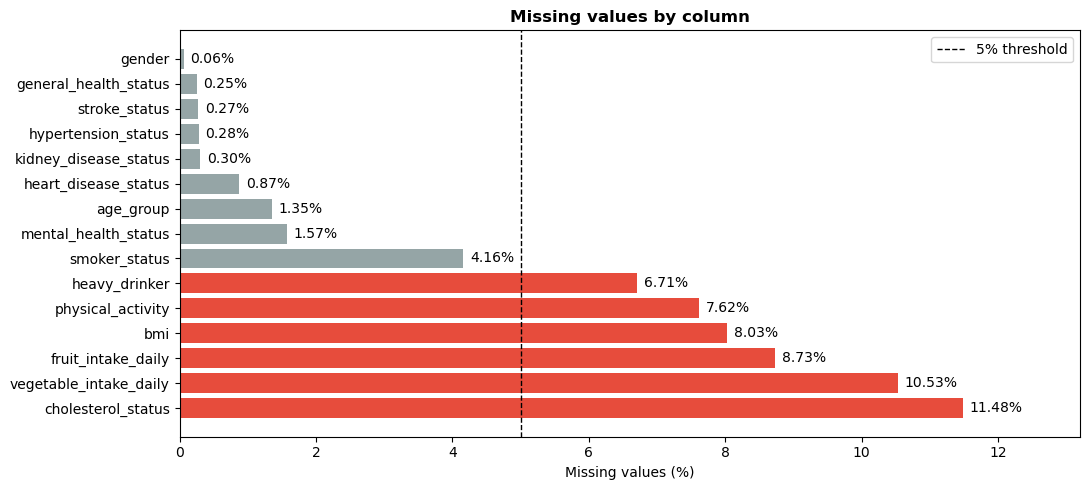

In [8]:
# check for missing values by column after preprocess
missing      = data.isna().sum().sort_values(ascending=False)
missing_pct  = (missing / len(data) * 100).round(2)
missing_plot = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    missing_plot.index,
    missing_plot.values,
    color=['#e74c3c' if v > 5 else '#95a5a6' for v in missing_plot.values],
)

ax.axvline(5, color='black', linestyle='--', lw=1, label='5% threshold')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing values by column', fontweight='bold')

ax.set_xlim(0, missing_plot.max() * 1.15)

for bar, v in zip(bars, missing_plot.values):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{v:.2f}%',
            va='center',
            fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

#### Listwise deletion for low-missingness variables (<1.5%)

We opted for listwise deletion for **gender, general_health_status, stroke_status, hypertension_status, kidney_disease_status, heart_disease_status, and age_group** because the proportion of missing data is too small to justify imputation, which would only add noise. Listwise deletion is both conservative and unbiased when missing data is rare and the MCAR assumption is reasonably met (Kang, 2013). This choice also aligns with the dominant practice in BRFSS-based diabetes prediction research: Masconi et al.'s (2015) systematic review reports that **43.8% of 48 comparable studies rely on case-wise deletion**.

In [9]:
listwise_drop_cols = [
    'gender', 'stroke_status', 'hypertension_status',
    'kidney_disease_status', 'general_health_status',
    'heart_disease_status', 'age_group',
]
n_before = len(data)
data = data.dropna(subset=listwise_drop_cols)
n_dropped = n_before - len(data)
print(f"Dropped {n_dropped:,} rows ({n_dropped/n_before*100:.2f}%) "
      f"with missing values")
print(f"Remaining: {len(data):,} rows")

Dropped 13,915 rows (3.18%) with missing values
Remaining: 423,789 rows


#### Median / mode imputation for moderate missingness, inside an **sklearn Pipeline**

For the remaining variable with moderate missingness, we will apply:

- **Median** imputation for continuous variables: bmi, mental_health_status
- **Mode** imputation for categorical variables: cholesterol_status, physical_activity, heavy_drinker, smoker_status, fruit_intake_daily, vegetable_intake_daily

This is the dominant approach in recent BRFSS-based diabetes ML work. Khaleel et al. (2024) report that missing values in categorical variables such as Age and Physical Activity were imputed using the mode, and continuous variables were imputed using the median. These methods were particularly effective in maintaining dataset integrity.

Critically, the imputer is fit inside an **sklearn Pipeline after train_test_split** so that imputation statistics are learned from training data only. Fitting an imputer on the full dataset before splitting is a common but subtle source of data leakage. Median/mode imputation is deliberately preferred over Multiple Imputation by Chained Equations (MICE) for two reasons: 

1. Lin et al. (2023) in a Monte Carlo study run *specifically on BRFSS*, found that *"these three methods [MICE, hot-deck, GERBIL] did not always outperform listwise deletion in our simulated missing patterns"*, so MICE's benefits over simpler approaches are not guaranteed on this dataset
2. for predictive ML at this sample size, simple imputation typically matches MICE on held-out performance while remaining trivially compatible with sklearn pipelines and cross-validation.



#### Add missingness indicator columns where refusal is informative

For **cholesterol_status, heavy_drinker,smoker_status and mental_health_status**, *refusal or don't know* is plausibly **not random**. Respondent who never had their cholesterol checked, or who decline to discuss alcohol or smoking, differ systematically from those who answer. We therefore will add binary **was_missing** flags **before** imputation so the model can use the missingness pattern itself as a feature. This is the **missing-indicator method** (Groenwold et al., 2012), endorsed for predictive modelling by Sperrin et al. (2020) on the grounds that
*missing patterns may convey important information* in prediction tasks, where the objective is forecast accuracy on new data rather than estimating unbiased causal effects.

#### 2.3.4 Outlier handling

Continuous variables in the BRFSS dataset, especially BMI, may contain biologically implausible values arising from data entry errors or self-report inaccuracies. Therefore, BMI was visually inspected using boxplots and histograms before deciding on the appropriate outlier treatment approach.

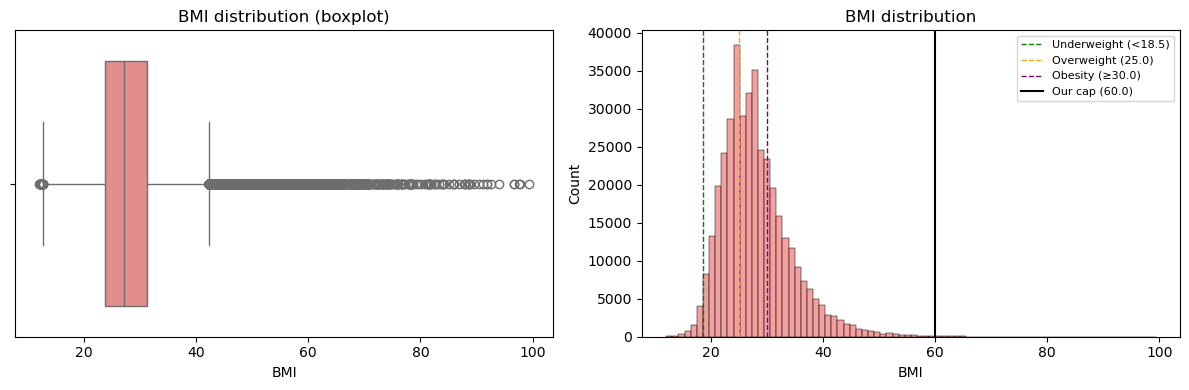

BMI summary statistics:
count    392282.000000
mean         28.111557
std           6.237652
min          12.010000
25%          23.800000
50%          27.120000
75%          31.180000
max          99.310000
Name: bmi, dtype: float64

Count BMI < 12: 0
Count BMI > 60: 504
Count BMI > 80: 42


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot of BMI, both for visual inspection and to see the whisker boundaries
sns.boxplot(x=data['bmi'], ax=axes[0], color='lightcoral')
axes[0].set_title('BMI distribution (boxplot)')
axes[0].set_xlabel('BMI')

sns.histplot(data['bmi'], bins=80, ax=axes[1], color='lightcoral')
axes[1].axvline(18.5, color='green', ls='--', lw=1, label='Underweight (<18.5)')
axes[1].axvline(25.0, color='orange', ls='--', lw=1, label='Overweight (25.0)')
axes[1].axvline(30.0, color='purple',    ls='--', lw=1, label='Obesity (≥30.0)')
axes[1].axvline(60.0, color='black',  ls='-',  lw=1.5, label='Our cap (60.0)')
axes[1].set_title('BMI distribution')
axes[1].set_xlabel('BMI')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('BMI summary statistics:')
print(data['bmi'].describe())

# Count biologically-implausible extreme values
print(f"\nCount BMI < 12: {(data['bmi'] < 12).sum():,}")
print(f"Count BMI > 60: {(data['bmi'] > 60).sum():,}")
print(f"Count BMI > 80: {(data['bmi'] > 80).sum():,}")

We cap BMI to the biologically reasonable range of **12 to 60** (Winsorisation). This is preferred over deletion because:

1. **Deletion loses information.** A respondent reporting BMI = 65 is super obese, but the rest of their record contains real information about every other variable (age, diabetes, etc) so deleting them wastes that information.
2. **Winsorisation is a standard robust-statistics technique** (Tukey, 1962) that limits the influence of extreme values without removing records.
3. **Our chosen bounds are grounded in WHO body-mass classifications.** BMI 12 is the lower bound of severe medical anorexia in adults while BMI 60 is the upper bound of verified super-obesity cases.

The cap is applied and the number of affected rows is recorded for transparency.

In [11]:
BMI_LOWER, BMI_UPPER = 12, 60
n_low  = (data['bmi'] < BMI_LOWER).sum()
n_high = (data['bmi'] > BMI_UPPER).sum()
data['bmi'] = data['bmi'].clip(lower=BMI_LOWER, upper=BMI_UPPER)
print(f'BMI winsorised to [{BMI_LOWER}, {BMI_UPPER}]: '
      f'{n_low} low values capped up, {n_high} high values capped down '
      f'({100*(n_low+n_high)/len(data):.3f}% of rows affected).')
print(f'BMI range after capping: [{data["bmi"].min():.2f}, {data["bmi"].max():.2f}]')

BMI winsorised to [12, 60]: 0 low values capped up, 504 high values capped down (0.119% of rows affected).
BMI range after capping: [12.01, 60.00]


### 2.4 Exploratory Data Analysis (EDA)

For EDA, several visualisations were created to better understand the data distribution and relationships between predictors and target.

The analysis includes:

1. **Target distribution** - diabetes prevalence and class imbalance
2. **Univariate analysis** - distribution of continuous and categorical variables
3. **Bivariate analysis** - diabetes prevalence across age group, gender, clinical conditions, lifestyle factors and self-rated health
4. **Stratified analysis** - diabetes prevalence across age with BMI and age with gender

To improve visual readability, a separate **df_plot data frame** is created using descriptive labels such as Yes/No and age-group names. The original numeric data is kept untouched so it can be use in the Phase 3 modelling pipeline.

In [12]:
# build a display copy of the data with category labels for plotting
# We KEEP the numeric data untouched for modelling, df_plot is purely for visualisation
label_map = {
    'diabetes_status':       {0: 'No', 1: 'Yes'},
    'heart_disease_status':         {0: 'No', 1: 'Yes'},
    'stroke_status':         {0: 'No', 1: 'Yes'},
    'kidney_disease_status': {0: 'No', 1: 'Yes'},
    'physical_activity':     {0: 'Inactive', 1: 'Active'},
    'heavy_drinker':         {0: 'No', 1: 'Yes'},
    'gender':                {0: 'Female', 1: 'Male'},
    'cholesterol_status':     {0: 'No', 1: 'Yes'},
    'hypertension_status':    {0: 'No', 1: 'Yes'},
    'fruit_intake_daily':          {0: 'No', 1: 'Yes'},
    'vegetable_intake_daily':      {0: 'No', 1: 'Yes'},
    'general_health_status': {1: 'Excellent', 2: 'Very good', 3: 'Good', 4: 'Fair', 5: 'Poor'},
    'age_group':             {1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
                              6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
                              11: '70-74', 12: '75-79', 13: '80+'},
    'smoker_status':         {1: 'Daily', 2: 'Sometimes', 3: 'Former', 4: 'Never'}
}
df_plot = data.copy()
for col, m in label_map.items():
    df_plot[col] = df_plot[col].map(m)
df_plot.head()

,seqno,state_code,diabetes_status,age_group,gender,bmi,fruit_intake_daily,vegetable_intake_daily,heavy_drinker,physical_activity,smoker_status,heart_disease_status,kidney_disease_status,stroke_status,cholesterol_status,hypertension_status,general_health_status,mental_health_status,unique_id
0,2017000001,1.0,Yes,70-74,Female,26.96,Yes,Yes,No,Active,Never,No,No,No,Yes,Yes,Very good,0.0,01_2017000001
1,2017000002,1.0,No,65-69,Male,29.43,Yes,Yes,No,Active,Never,No,No,No,No,Yes,Very good,0.0,01_2017000002
2,2017000003,1.0,No,70-74,Male,25.04,No,No,No,Inactive,Never,No,No,No,Yes,No,Good,0.0,01_2017000003
3,2017000004,1.0,Yes,70-74,Female,26.63,No,NaN,No,NaN,Never,No,No,No,Yes,Yes,Fair,0.0,01_2017000004
4,2017000005,1.0,No,65-69,Female,23.30,Yes,No,No,Inactive,Former,No,No,No,No,No,Fair,0.0,01_2017000005


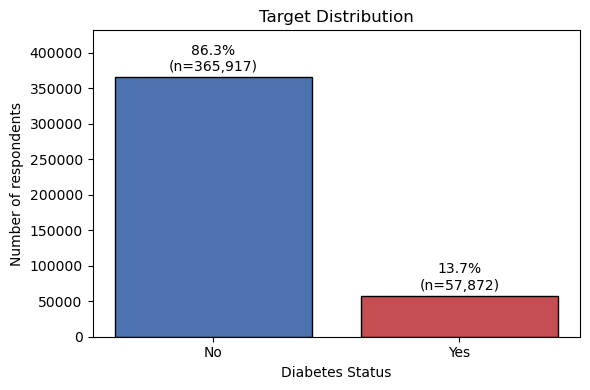

Diabetes prevalence in this dataset: 13.66%
Imbalance ratio (No : Yes): 6.3 : 1


In [13]:
# target variable distribution
fig, ax = plt.subplots(figsize=(6, 4))
target_counts = df_plot['diabetes_status'].value_counts()
bars = ax.bar(target_counts.index, target_counts.values,
              color=['#4C72B0', '#C44E52'], edgecolor='black')

total = target_counts.sum()

for bar, n in zip(bars, target_counts.values):
    perc = 100 * n / total
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + total * 0.02,
            f'{perc:.1f}%\n(n={n:,})',
            ha='center',
            fontsize=10)

ax.set_title('Target Distribution')
ax.set_xlabel('Diabetes Status')
ax.set_ylabel('Number of respondents')
ax.set_ylim(0, max(target_counts.values) * 1.18)

plt.tight_layout()
plt.show()

prevalence = data['diabetes_status'].mean() * 100
print(f'Diabetes prevalence in this dataset: {prevalence:.2f}%')
print(f'Imbalance ratio (No : Yes): {(data["diabetes_status"]==0).sum() / (data["diabetes_status"]==1).sum():.1f} : 1')

- The distribution shows a moderate class imbalance, with roughly 13.7 per cent of respondents reporting diabetes
- As a result, we cannot use accuracy as the primary success metric, and will prioritize using PR-AUC, recall, ROC-AUC and F1/F2 score and Brier score during evaluation
- To ensure the model learns to identify diabetes effectively, we must implement techniques like random undersampling or SMOTE or class weighting during the training phase


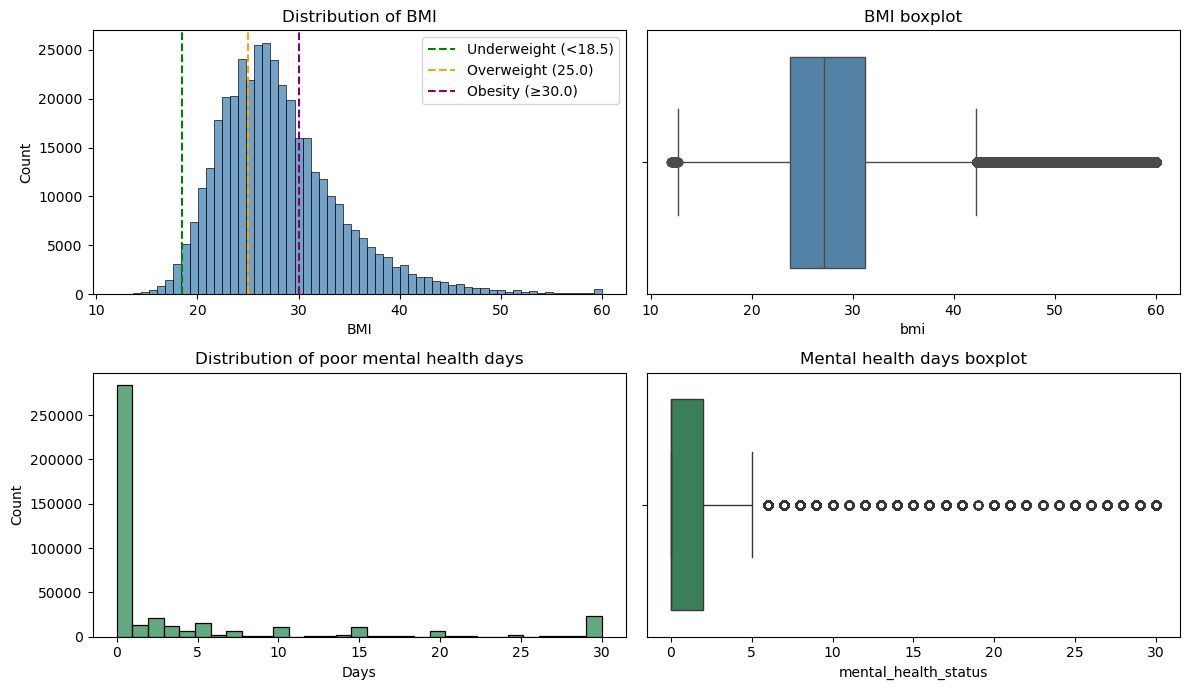

             bmi  mental_health_status
count  392282.00             417681.00
mean       28.10                  3.53
std         6.18                  7.82
min        12.01                  0.00
25%        23.80                  0.00
50%        27.12                  0.00
75%        31.18                  2.00
max        60.00                 30.00


In [14]:
# Continuous / count variables: histogram + boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sns.histplot(data['bmi'], bins=60, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of BMI')
axes[0, 0].set_xlabel('BMI')

axes[0, 0].axvline(18.5, color='green',  ls='--', lw=1.5, label='Underweight (<18.5)')
axes[0, 0].axvline(25.0, color='orange', ls='--', lw=1.5, label='Overweight (25.0)')
axes[0, 0].axvline(30.0, color='purple', ls='--', lw=1.5, label='Obesity (≥30.0)')
axes[0, 0].legend()

sns.boxplot(x=data['bmi'], ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('BMI boxplot')

sns.histplot(data['mental_health_status'], bins=31, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Distribution of poor mental health days')
axes[1, 0].set_xlabel('Days')

sns.boxplot(x=data['mental_health_status'], ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('Mental health days boxplot')
plt.tight_layout()
plt.show()

print(data[['bmi', 'mental_health_status']].describe().round(2))

BMI:
- Right-skewed distribution with mean 28.10 above median 27.12, and IQR 23.80 to 31.18 showing the middle 50 percent fall in the overweight category
- Visible concentrations at BMI 12 and 60 are expected artifacts of winsorisation applied during outlier handling

Mental Health Days:
- Majority of the respondent reported zero poor mental health days, with the median and Q1 both at zero
- Although most report no distress, the mean 3.53 and standard deviation 7.82 are pulled upward by a smaller subgroup with many distress days
- A secondary peak reflects respondents reporting daily distress for the entire month, identifying a chronically distressed subgroup

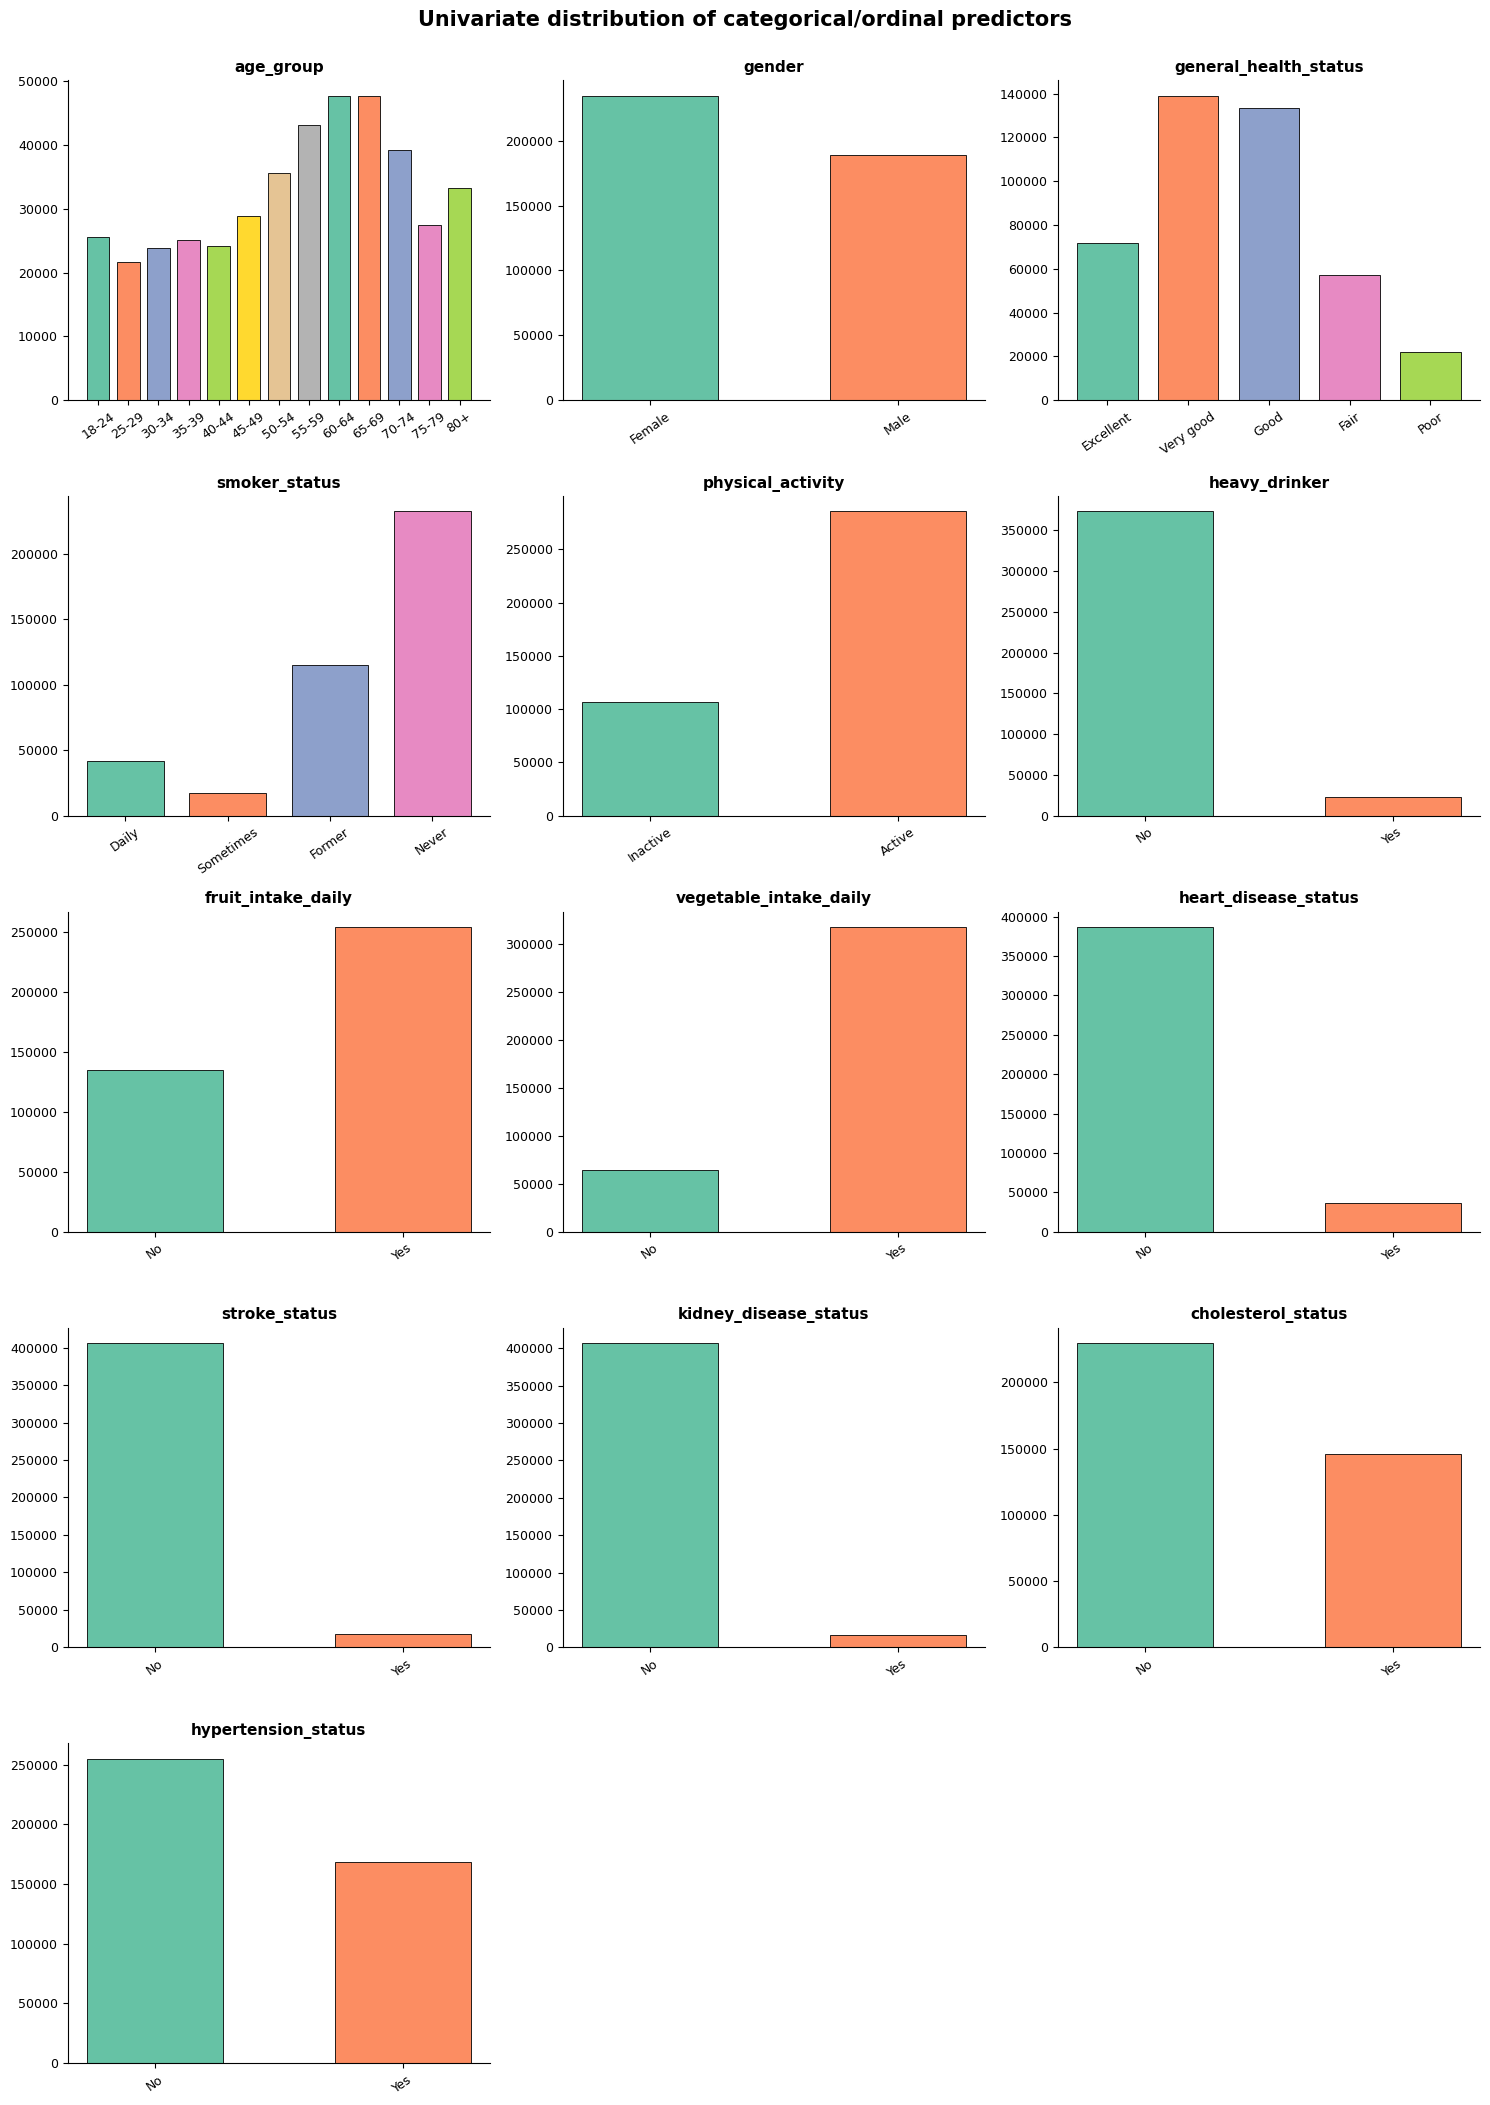

In [15]:
cat_vars = ['age_group', 'gender', 'general_health_status', 'smoker_status',
            'physical_activity', 'heavy_drinker',
            'fruit_intake_daily', 'vegetable_intake_daily',
            'heart_disease_status', 'stroke_status', 'kidney_disease_status',
            'cholesterol_status', 'hypertension_status']

category_orders = {
    'age_group': ['18-24','25-29','30-34','35-39','40-44','45-49','50-54',
                  '55-59','60-64','65-69','70-74','75-79','80+'],
    'general_health_status': ['Excellent','Very good','Good','Fair','Poor'],
    'smoker_status': ['Daily','Sometimes','Former','Never'],
    'gender': ['Female', 'Male'],
    'physical_activity': ['Inactive', 'Active'],
    'heavy_drinker': ['No', 'Yes'],
    'fruit_intake_daily': ['No', 'Yes'],
    'vegetable_intake_daily': ['No', 'Yes'],
    'heart_disease_status': ['No','Yes'],
    'stroke_status': ['No','Yes'],
    'kidney_disease_status': ['No','Yes'],
    'cholesterol_status': ['No','Yes'],
    'hypertension_status': ['No','Yes'],
}

n_cols = 3
n_rows = -(-len(cat_vars) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    ax = axes[i]
    counts = df_plot[col].value_counts()
    if col in category_orders:
        counts = counts.reindex(category_orders[col])

    bar_width = 0.55 if len(counts) <= 3 else 0.75
    colors = sns.color_palette('Set2', len(counts))

    ax.bar(counts.index.astype(str), counts.values,
           width=bar_width, color=colors,
           edgecolor='black', linewidth=0.6)

    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

for j in range(len(cat_vars), len(axes)):
    axes[j].axis('off')

plt.suptitle('Univariate distribution of categorical/ordinal predictors',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

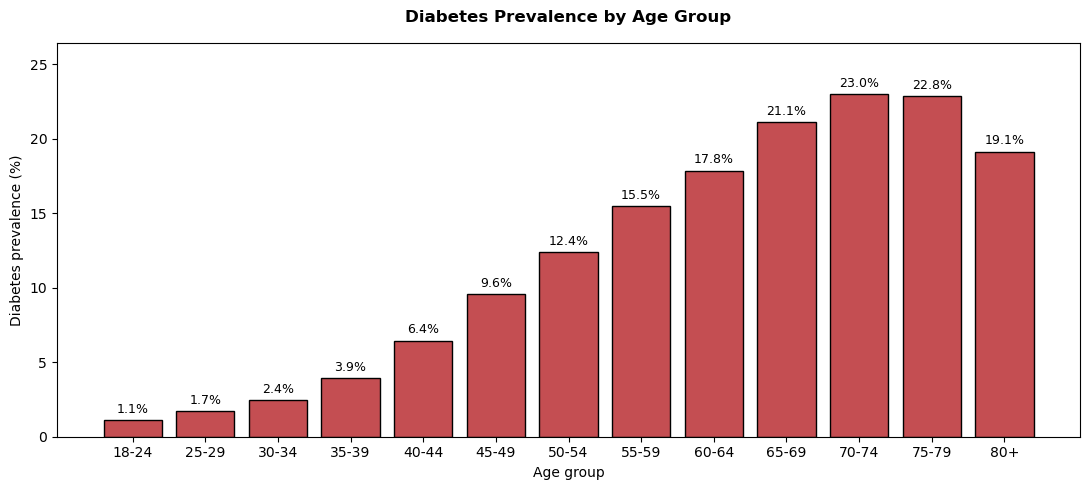

In [16]:
# Diabetes prevalence by age group
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']

age_hd = (df_plot.groupby('age_group')['diabetes_status']
          .value_counts(normalize=True)
          .mul(100)
          .rename('pct')
          .reset_index())

age_hd_yes = (age_hd[age_hd['diabetes_status'] == 'Yes']
              .set_index('age_group').reindex(age_order)
              .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(age_hd_yes['age_group'], age_hd_yes['pct'],
              color='#C44E52', edgecolor='black')

for bar, pct in zip(bars, age_hd_yes['pct']):
    if not np.isnan(pct):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=9)

ax.set_title('Diabetes Prevalence by Age Group', fontweight='bold', pad=15)
ax.set_xlabel('Age group')
ax.set_ylabel('Diabetes prevalence (%)')
ax.set_ylim(0, age_hd_yes['pct'].max() * 1.15)

plt.tight_layout()
plt.show()

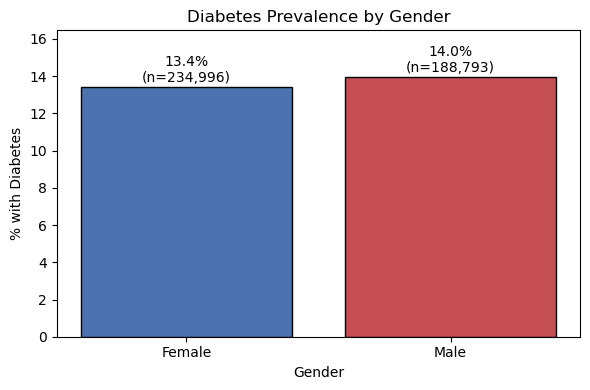

Female: 13.42% prevalence (n=234,996)
Male: 13.95% prevalence (n=188,793)


In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

# % of each gender that has diabetes
gender_prev = df_plot.groupby('gender')['diabetes_status'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
gender_counts = df_plot.groupby('gender').size()

bars = ax.bar(gender_prev.index, gender_prev.values,
              color=['#4C72B0', '#C44E52'], edgecolor='black')

for bar, pct, n in zip(bars, gender_prev.values, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(gender_prev.values)*0.02,
            f'{pct:.1f}%\n(n={n:,})', ha='center', fontsize=10)

ax.set_title('Diabetes Prevalence by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('% with Diabetes')
ax.set_ylim(0, max(gender_prev.values) * 1.18)
plt.tight_layout()
plt.show()

# Summary stats
for g in gender_prev.index:
    print(f'{g}: {gender_prev[g]:.2f}% prevalence (n={gender_counts[g]:,})')
diff = gender_prev.max() - gender_prev.min()

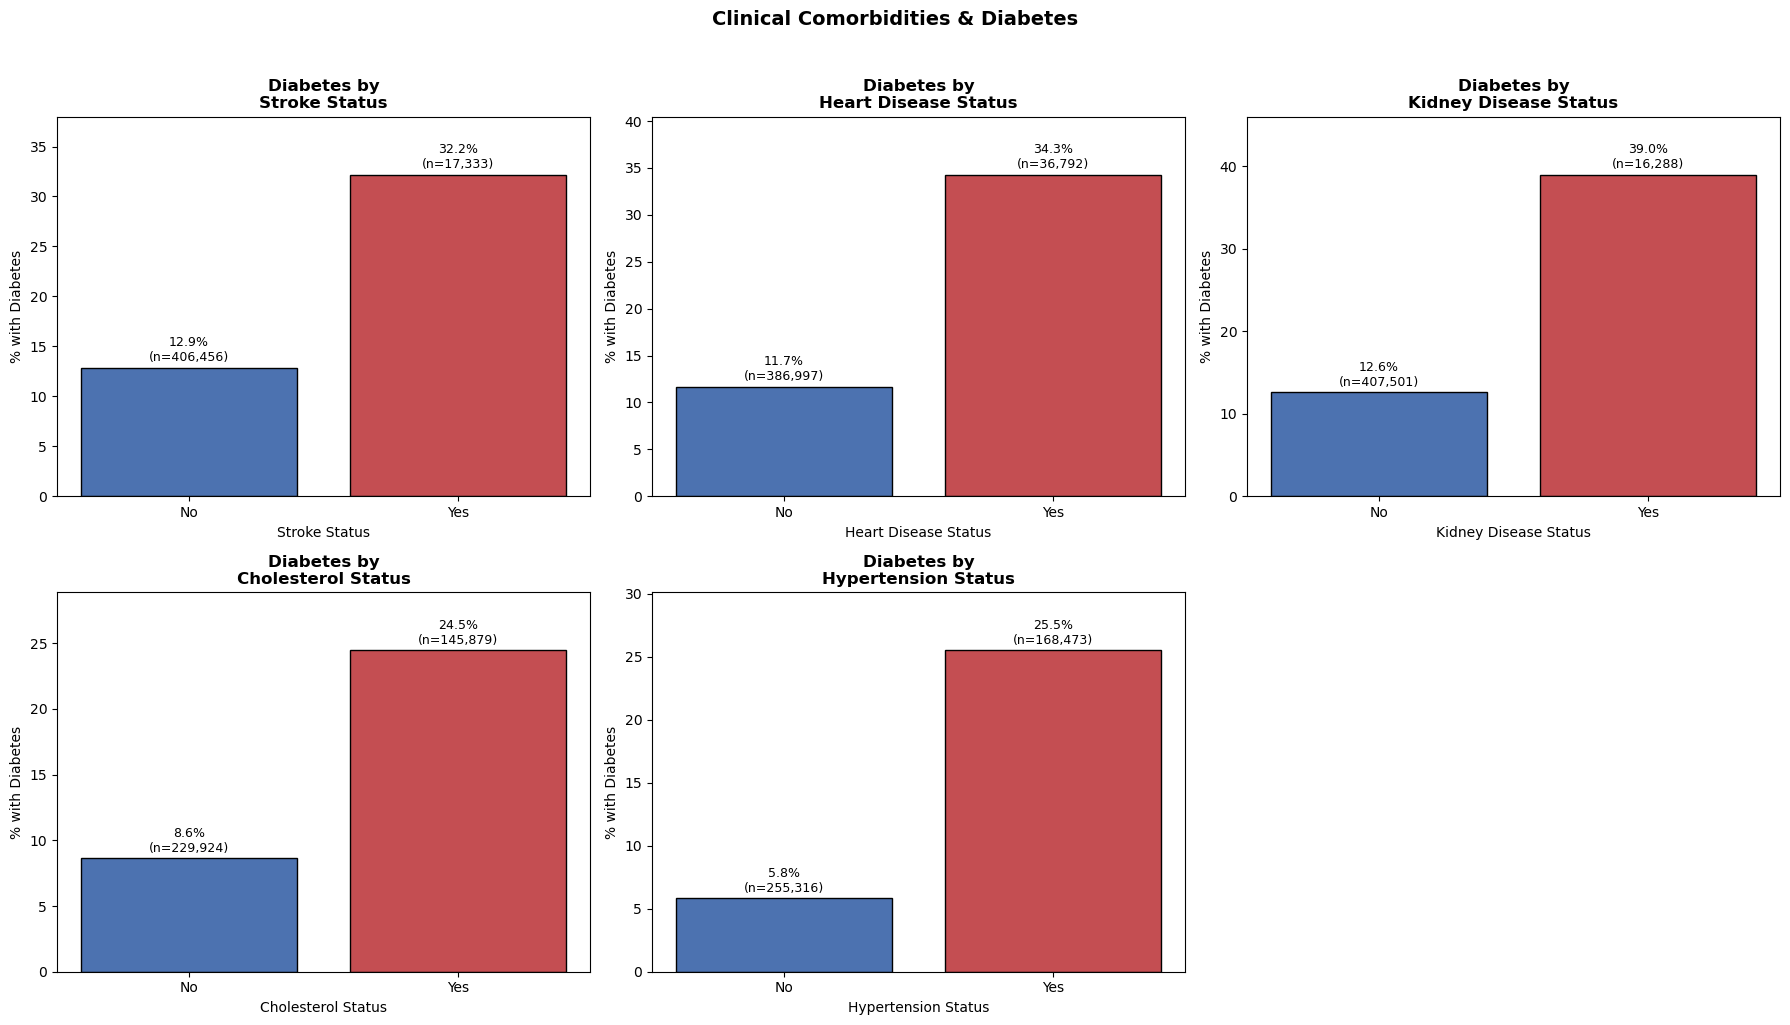


Stroke Status:
  No: 12.87% prevalence (n=406,456)
  Yes: 32.19% prevalence (n=17,333)
  Prevalence gap: 19.32 percentage points

Heart Disease Status:
  No: 11.69% prevalence (n=386,997)
  Yes: 34.29% prevalence (n=36,792)
  Prevalence gap: 22.59 percentage points

Kidney Disease Status:
  No: 12.64% prevalence (n=407,501)
  Yes: 38.99% prevalence (n=16,288)
  Prevalence gap: 26.35 percentage points

Cholesterol Status:
  No: 8.63% prevalence (n=229,924)
  Yes: 24.47% prevalence (n=145,879)
  Prevalence gap: 15.84 percentage points

Hypertension Status:
  No: 5.82% prevalence (n=255,316)
  Yes: 25.54% prevalence (n=168,473)
  Prevalence gap: 19.72 percentage points


In [18]:
# Diabetes prevalence by binary clinical conditions
binary_clinical = ['stroke_status', 'heart_disease_status', 'kidney_disease_status', 'cholesterol_status', 'hypertension_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, col in enumerate(binary_clinical):
    ax = axes_flat[i]
    
    # Prevalence and group size for each category in the condition
    prev = df_plot.groupby(col)['diabetes_status'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )
    counts = df_plot.groupby(col).size()

    bars = ax.bar(prev.index.astype(str), prev.values,
                  color=['#4C72B0', '#C44E52'], edgecolor='black')

    for bar, pct, n in zip(bars, prev.values, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(prev.values)*0.02,
                f'{pct:.1f}%\n(n={n:,})', ha='center', fontsize=9)

    ax.set_title(f'Diabetes by\n{col.replace("_", " ").title()}',
                 fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('% with Diabetes')
    ax.set_ylim(0, max(prev.values) * 1.18)

axes_flat[5].set_visible(False)

plt.suptitle('Clinical Comorbidities & Diabetes',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Summary stats per condition
for col in binary_clinical:
    prev = df_plot.groupby(col)['diabetes_status'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )
    counts = df_plot.groupby(col).size()
    print(f'\n{col.replace("_", " ").title()}:')
    for cat in prev.index:
        print(f'  {cat}: {prev[cat]:.2f}% prevalence (n={counts[cat]:,})')
    gap = prev.max() - prev.min()
    print(f'  Prevalence gap: {gap:.2f} percentage points')

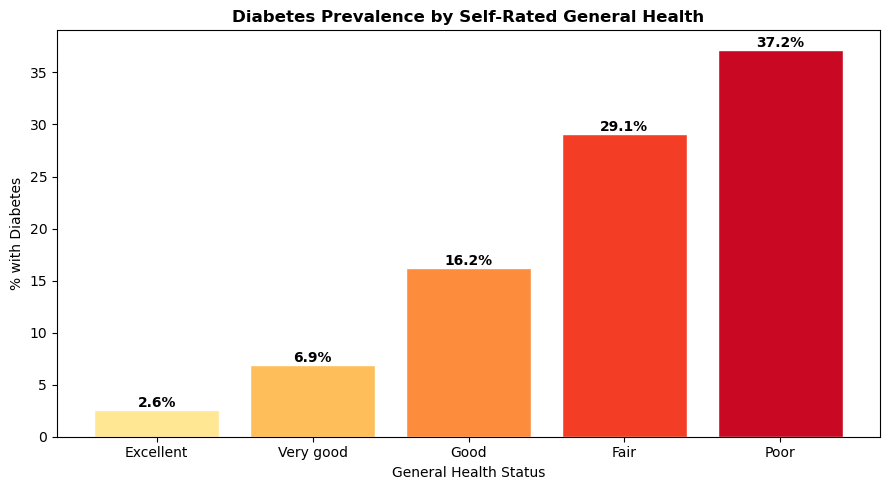

Prevalence in Excellent self-rated: 2.57%
Prevalence in Poor self-rated:      37.19%
Ratio (Poor / Excellent): 14.5x


In [19]:
# General health status
gh_order = ['Excellent', 'Very good', 'Good', 'Fair', 'Poor']
gh_hd = (df_plot.groupby('general_health_status')['diabetes_status']
         .value_counts(normalize=True).mul(100)
         .rename('pct').reset_index())
gh_yes = (gh_hd[gh_hd['diabetes_status']=='Yes']
          .set_index('general_health_status').reindex(gh_order)
          .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(gh_yes['general_health_status'], gh_yes['pct'],
              color=sns.color_palette('YlOrRd', 5), edgecolor='white')
ax.set_title('Diabetes Prevalence by Self-Rated General Health', fontweight='bold')
ax.set_xlabel('General Health Status')
ax.set_ylabel('% with Diabetes')
for bar, val in zip(bars, gh_yes['pct'].fillna(0)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute the gradient
ex_pct = gh_yes.loc[gh_yes['general_health_status']=='Excellent', 'pct'].values[0]
poor_pct = gh_yes.loc[gh_yes['general_health_status']=='Poor', 'pct'].values[0]
print(f'Prevalence in Excellent self-rated: {ex_pct:.2f}%')
print(f'Prevalence in Poor self-rated:      {poor_pct:.2f}%')
print(f'Ratio (Poor / Excellent): {poor_pct/ex_pct:.1f}x')

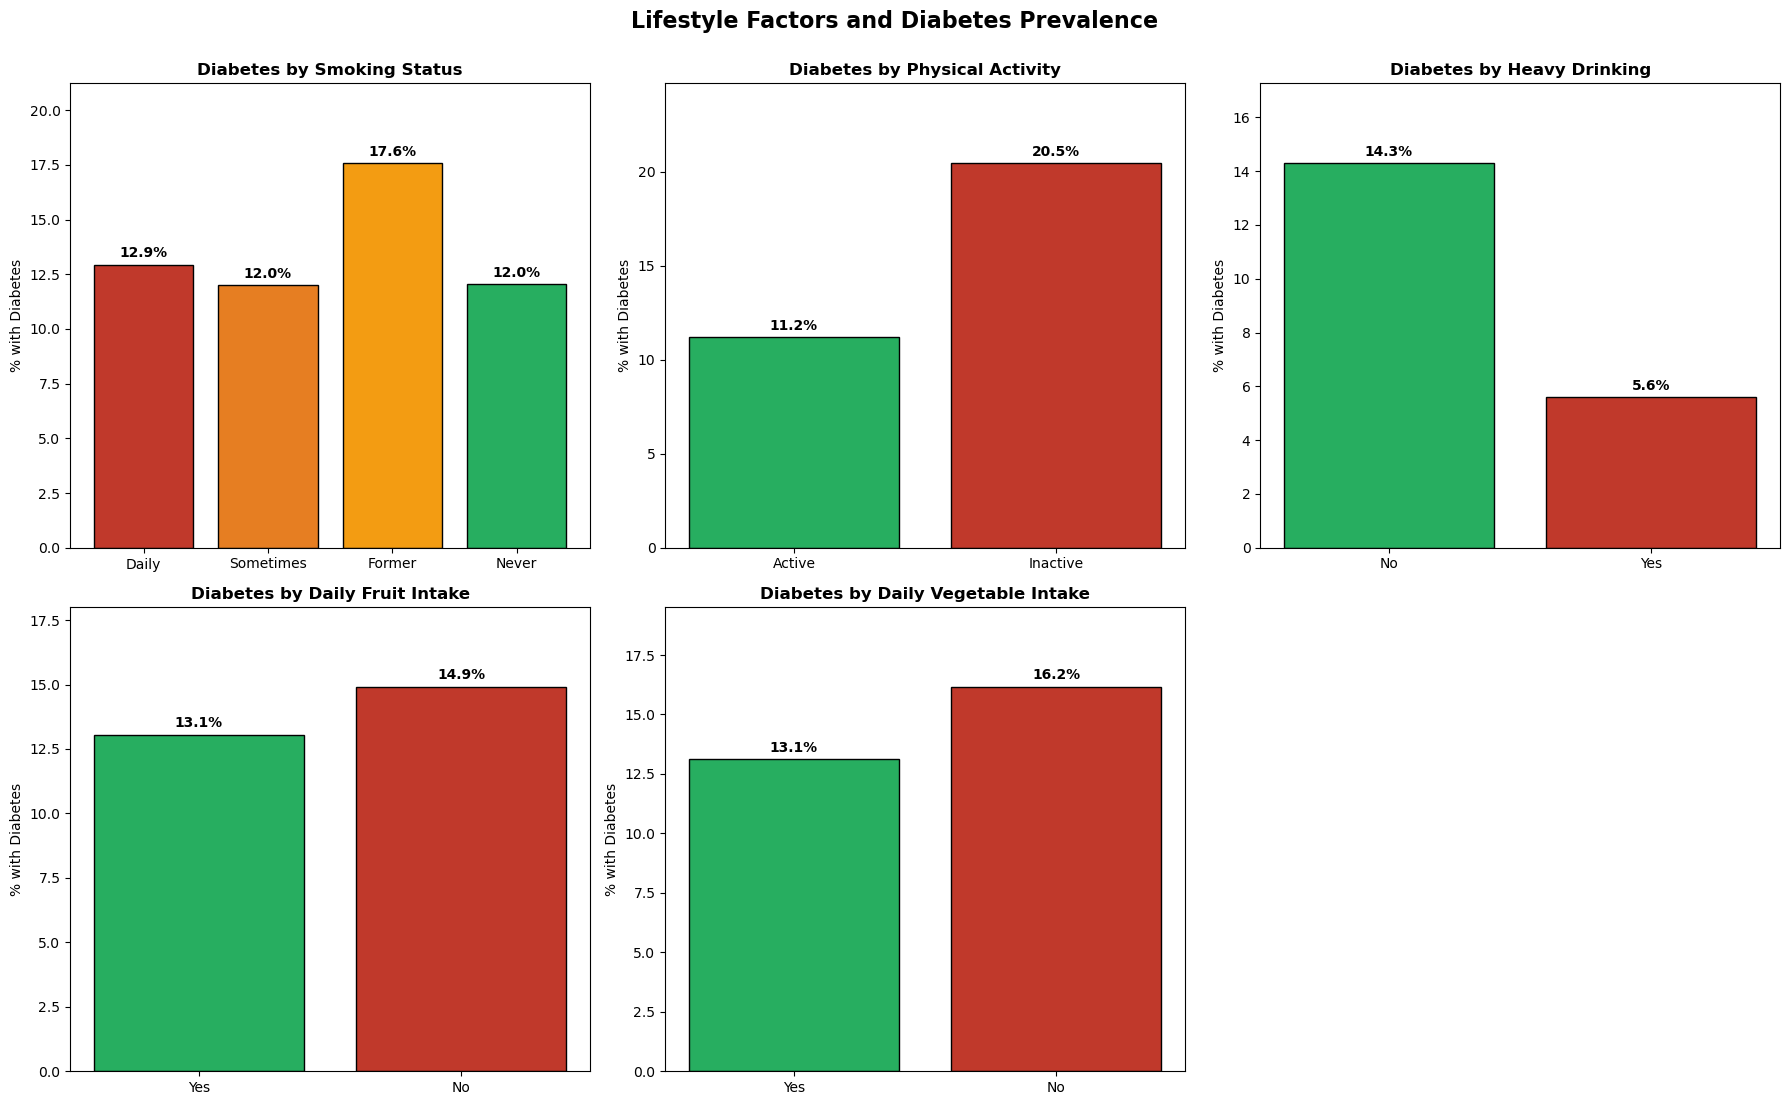

In [20]:
# Setup for the 5 subplots 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# smoker status
smoke_order = ['Daily', 'Sometimes', 'Former', 'Never']
smoke_stats = (df_plot.groupby('smoker_status')['diabetes_status']
               .value_counts(normalize=True).mul(100)
               .unstack(fill_value=0))
smoke_stats = smoke_stats.reindex(smoke_order)
bars0 = axes[0].bar(smoke_stats.index, smoke_stats['Yes'],
                    color=['#c0392b','#e67e22','#f39c12','#27ae60'], edgecolor='black')
axes[0].set_title('Diabetes by Smoking Status', fontweight='bold')
axes[0].set_ylabel('% with Diabetes')
axes[0].bar_label(bars0, labels=[f'{v:.1f}%' for v in smoke_stats['Yes']],
                  padding=3, fontweight='bold')

# physical activity
pa_order = ['Active', 'Inactive']
pa_stats = (df_plot.groupby('physical_activity')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
pa_stats = pa_stats.reindex(pa_order)
bars1 = axes[1].bar(pa_stats.index, pa_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[1].set_title('Diabetes by Physical Activity', fontweight='bold')
axes[1].set_ylabel('% with Diabetes')
axes[1].bar_label(bars1, labels=[f'{v:.1f}%' for v in pa_stats['Yes']],
                  padding=3, fontweight='bold')

# heavy drinker
hd_order = ['No', 'Yes']
hd_stats = (df_plot.groupby('heavy_drinker')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
hd_stats = hd_stats.reindex(hd_order)
bars2 = axes[2].bar(hd_stats.index, hd_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[2].set_title('Diabetes by Heavy Drinking', fontweight='bold')
axes[2].set_ylabel('% with Diabetes')
axes[2].bar_label(bars2, labels=[f'{v:.1f}%' for v in hd_stats['Yes']],
                  padding=3, fontweight='bold')

# daily fruit intake
fr_order = ['Yes', 'No']
fr_stats = (df_plot.groupby('fruit_intake_daily')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
fr_stats = fr_stats.reindex(fr_order)
bars3 = axes[3].bar(fr_stats.index, fr_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[3].set_title('Diabetes by Daily Fruit Intake', fontweight='bold')
axes[3].set_ylabel('% with Diabetes')
axes[3].bar_label(bars3, labels=[f'{v:.1f}%' for v in fr_stats['Yes']],
                  padding=3, fontweight='bold')

# daily vegetable intake
vg_order = ['Yes', 'No']
vg_stats = (df_plot.groupby('vegetable_intake_daily')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
vg_stats = vg_stats.reindex(vg_order)
bars4 = axes[4].bar(vg_stats.index, vg_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[4].set_title('Diabetes by Daily Vegetable Intake', fontweight='bold')
axes[4].set_ylabel('% with Diabetes')
axes[4].bar_label(bars4, labels=[f'{v:.1f}%' for v in vg_stats['Yes']],
                  padding=3, fontweight='bold')

axes[5].axis('off')
for ax in axes[:5]:
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.suptitle('Lifestyle Factors and Diabetes Prevalence',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

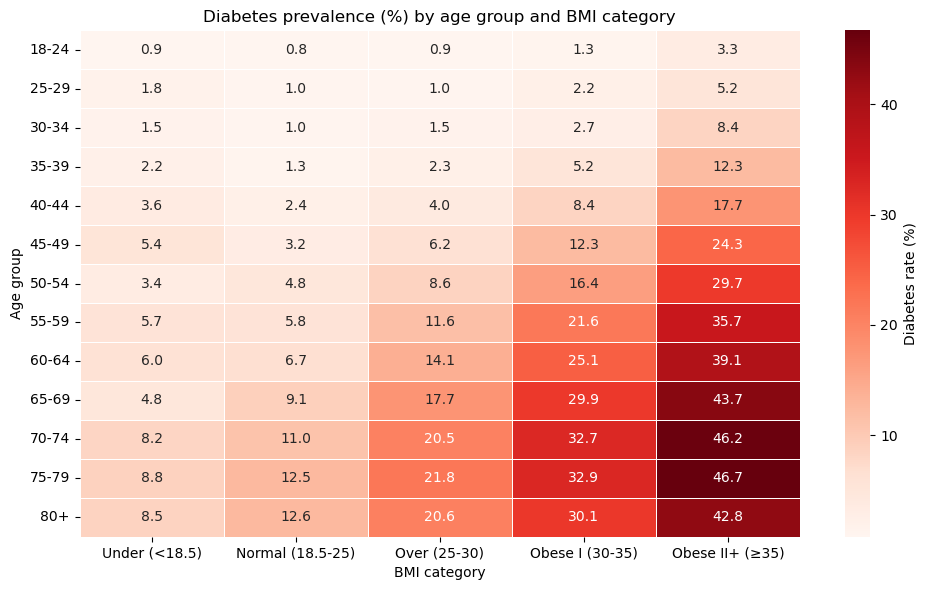

In [21]:
bmi_bins   = [0, 18.5, 25, 30, 35, 100]
bmi_labels = ['Under (<18.5)', 'Normal (18.5-25)', 'Over (25-30)',
              'Obese I (30-35)', 'Obese II+ (≥35)']
tmp = data.copy()
tmp['_bmi_cat'] = pd.cut(tmp['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)

heat = (tmp.groupby(['age_group','_bmi_cat'], observed=True)['diabetes_status']
           .mean().unstack() * 100)
heat.index = [label_map['age_group'][int(i)] for i in heat.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Diabetes rate (%)'},
            linewidth=0.5, linecolor='white', ax=ax)
ax.set_title('Diabetes prevalence (%) by age group and BMI category')
ax.set_xlabel('BMI category')
ax.set_ylabel('Age group')
plt.tight_layout()
plt.show()

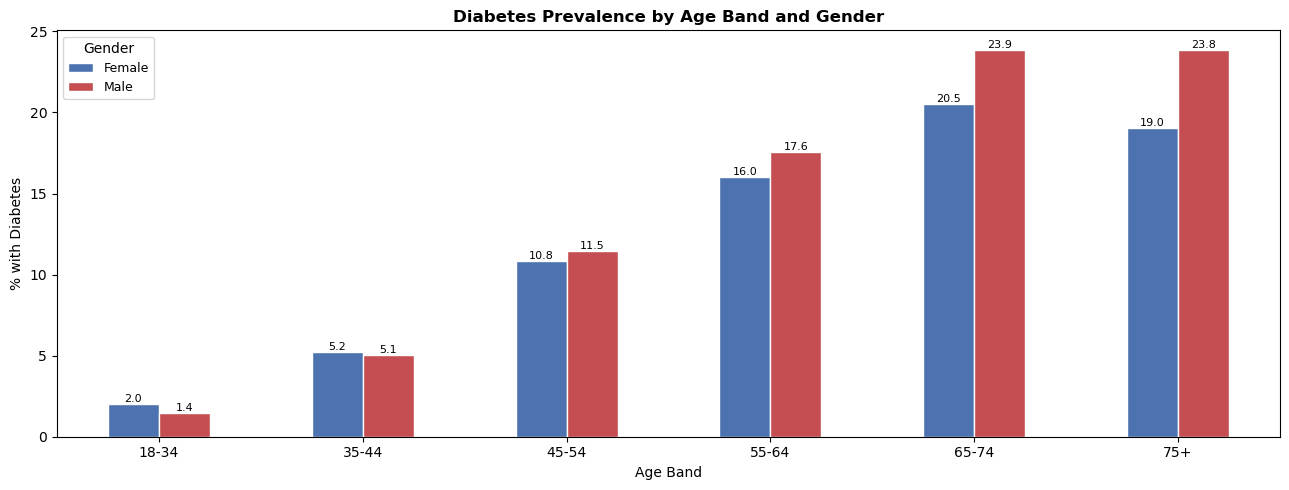

Diabetes prevalence (%) by age band and gender:
gender_label  Female   Male
age_band                   
18-34           2.02   1.45
35-44           5.23   5.06
45-54          10.82  11.47
55-64          16.03  17.56
65-74          20.51  23.87
75+            19.05  23.83

Male-to-Female prevalence ratio by age band:
gender_label  M:F ratio
age_band               
18-34              0.72
35-44              0.97
45-54              1.06
55-64              1.10
65-74              1.16
75+                1.25


In [22]:
# Heart disease prevalence by age band and gender
data_strat = data.copy()
data_strat['age_group_label'] = data_strat['age_group'].map(label_map['age_group'])

# Group ages into broader bands for cleaner plot
def age_band(a):
    if a in ['18-24','25-29','30-34']:return '18-34'
    elif a in ['35-39','40-44']:return '35-44'
    elif a in ['45-49','50-54']:return '45-54'
    elif a in ['55-59','60-64']:return '55-64'
    elif a in ['65-69','70-74']:return '65-74'
    else:return '75+'

data_strat['age_band'] = data_strat['age_group_label'].apply(age_band)
data_strat['gender_label'] = data_strat['gender'].map(label_map['gender'])
strat_g = (data_strat.groupby(['age_band', 'gender_label'])['diabetes_status']
           .mean().mul(100).reset_index(name='prevalence'))

pivot_g = strat_g.pivot(index='age_band', columns='gender_label', values='prevalence')
pivot_g = pivot_g.reindex(['18-34','35-44','45-54','55-64','65-74','75+'])
pivot_g = pivot_g[['Female', 'Male']]

fig, ax = plt.subplots(figsize=(13, 5))
pivot_g.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], edgecolor='white')
ax.set_title('Diabetes Prevalence by Age Band and Gender',
             fontweight='bold')
ax.set_xlabel('Age Band')
ax.set_ylabel('% with Diabetes')
ax.legend(title='Gender', fontsize=9)
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8)
plt.tight_layout()
plt.show()

print('Diabetes prevalence (%) by age band and gender:')
print(pivot_g.round(2))

# Compute male-to-female ratio to quantify how the gender gap changes with age
pivot_g['M:F ratio'] = (pivot_g['Male'] / pivot_g['Female']).round(2)
print('\nMale-to-Female prevalence ratio by age band:')
print(pivot_g[['M:F ratio']])

### 2.5 Correlation Analysis with the Target

Three complementary association measures are used to analyse relationships between predictors and the target:

1. Mutual Information - captures linear and non-linear relationships for all feature types
2. Bias-corrected Cramer’s V - measures association strength for categorical variables
3. Point-Biserial and Spearman correlation - measures associations between continuous variables and the target

These methods provide an early indication of feature importance before model training.

To avoid biasing the association estimates with imputed values, each measure is calculated using pairwise complete cases for the corresponding feature. This pairwise-deletion approach is a standard practice in descriptive statistics, as it helps prevent the spurious associations that can arise from single-pass median or mode imputation. The actual modelling pipeline in Phase 3 performs imputation exclusively on the training data to avoid data leakage.

In [23]:
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import pointbiserialr, spearmanr, chi2_contingency

CONTINUOUS = ['bmi', 'mental_health_status']
CATEGORICAL = ['age_group', 'gender', 'fruit_intake_daily', 'vegetable_intake_daily',
               'heavy_drinker', 'physical_activity', 'smoker_status',
               'heart_disease_status', 'kidney_disease_status', 'stroke_status',
               'cholesterol_status', 'hypertension_status', 'general_health_status']
FEATURES = CATEGORICAL + CONTINUOUS
TARGET = 'diabetes_status'

# Computing MI per feature on the subset of rows where THAT feature is non-missing
# avoids the downward bias that comes from imputing the whole frame before MI.
DISCRETE_FOR_MI = set(CATEGORICAL) | {'mental_health_status'}

mi_records = []
for feat in FEATURES:
    sub = data[[feat, TARGET]].dropna()
    is_discrete = feat in DISCRETE_FOR_MI
    mi_val = mutual_info_classif(
        sub[[feat]],
        sub[TARGET].astype(int),
        discrete_features=[is_discrete],
        random_state=42,
    )[0]
    mi_records.append({'feature': feat, 'mutual_info': mi_val, 'n': len(sub)})

mi_df = (pd.DataFrame(mi_records)
           .sort_values('mutual_info', ascending=False)
           .reset_index(drop=True))


# Bias-corrected Cramer's V (pairwise complete cases)
def cramers_v(x, y):
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    phi2_corr = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0


v_df = (pd.DataFrame({
            'feature': CATEGORICAL,
            'cramers_v': [cramers_v(data[c], data[TARGET]) for c in CATEGORICAL],
        })
        .sort_values('cramers_v', ascending=False)
        .reset_index(drop=True))


# Continuous vs binary target: point-biserial + Spearman
cont_records = []
for c in CONTINUOUS:
    sub = data[[c, TARGET]].dropna()
    pb_r, pb_p = pointbiserialr(sub[TARGET].astype(int), sub[c])
    sp_r, sp_p = spearmanr(sub[c], sub[TARGET].astype(int))
    cont_records.append({
        'feature': c,
        'point_biserial_r': pb_r, 'pb_pvalue': pb_p,
        'spearman_rho': sp_r, 'spearman_pvalue': sp_p,
        'n': len(sub),
    })
cont_df = pd.DataFrame(cont_records)

print('Mutual Information (top 5):')
print(mi_df.head(5).to_string(index=False))
print("\nCramer's V (top 5):")
print(v_df.head(5).to_string(index=False))
print('\nContinuous-vs-target associations:')
print(cont_df.to_string(index=False))

Mutual Information (top 5):
              feature  mutual_info      n
general_health_status     0.040883 423789
  hypertension_status     0.039120 423789
            age_group     0.029905 423789
                  bmi     0.029251 392282
   cholesterol_status     0.023053 375803

Cramer's V (top 5):
              feature  cramers_v
general_health_status   0.289396
  hypertension_status   0.281021
            age_group   0.222273
   cholesterol_status   0.217547
 heart_disease_status   0.185252

Continuous-vs-target associations:
             feature  point_biserial_r     pb_pvalue  spearman_rho  spearman_pvalue      n
                 bmi          0.232258  0.000000e+00      0.223603     0.000000e+00 392282
mental_health_status          0.056336 1.065954e-290      0.029888     3.640096e-83 417681


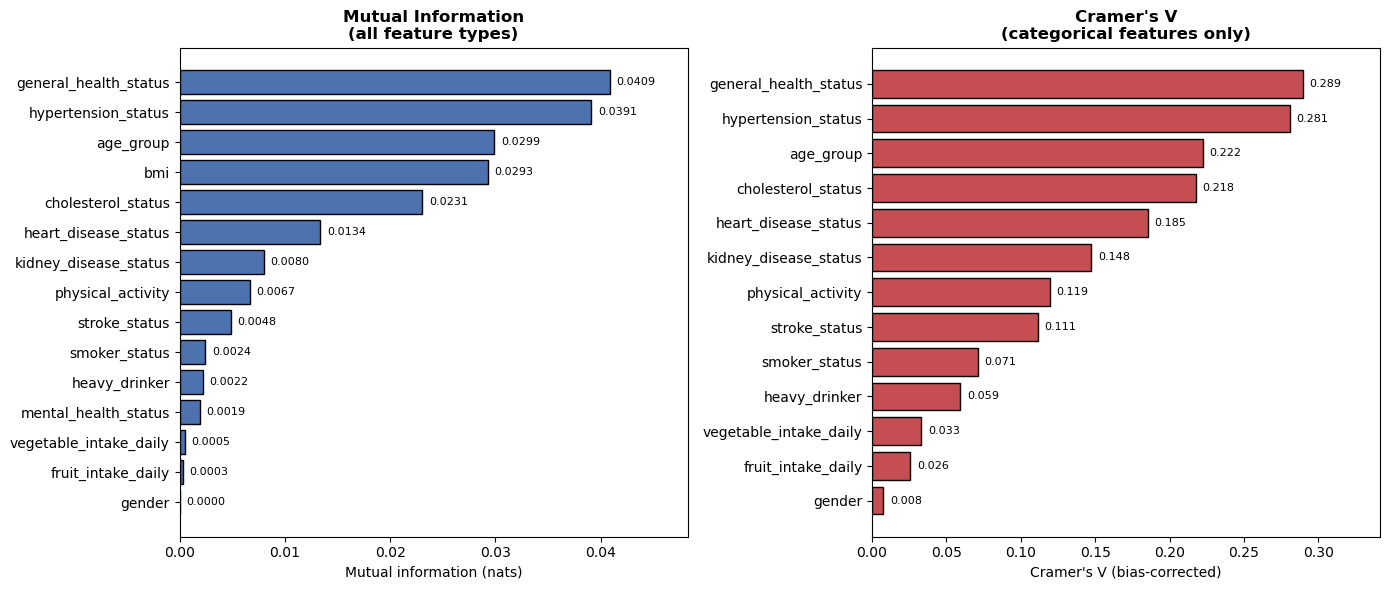

In [24]:
# visualise the association measures side by side for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Mutual Information
mi_max = mi_df['mutual_info'].max()
mi_pad = mi_max * 0.015                    
axes[0].barh(mi_df['feature'][::-1], mi_df['mutual_info'][::-1],
             color='#4C72B0', edgecolor='black')
axes[0].set_title('Mutual Information\n(all feature types)',
                  fontweight='bold')
axes[0].set_xlabel('Mutual information (nats)')
axes[0].set_xlim(0, mi_max * 1.18)         
for i, v in enumerate(mi_df['mutual_info'][::-1]):
    axes[0].text(v + mi_pad, i, f'{v:.4f}', va='center', fontsize=8)

# Right: Cramer's V
v_max = v_df['cramers_v'].max()
v_pad = v_max * 0.015
axes[1].barh(v_df['feature'][::-1], v_df['cramers_v'][::-1],
             color='#C44E52', edgecolor='black')
axes[1].set_title("Cramer's V\n(categorical features only)",
                  fontweight='bold')
axes[1].set_xlabel("Cramer's V (bias-corrected)")
axes[1].set_xlim(0, v_max * 1.18)
for i, v in enumerate(v_df['cramers_v'][::-1]):
    axes[1].text(v + v_pad, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Phase 3: Data Preparation

### 3.1 Feature Engineering for Missingness Indicators

Previously in Phase 2, we flagged three variables where *refusal* or *don't know* is unlikely to be random: **`cholesterol_status`**, **`heavy_drinker`**,**`smoker_status`** and **`mental_health_status`**. Respondents who have never had their cholesterol checked, or who decline to discuss alcohol consumption, differ systematically from those who answer and that pattern of refusal is itself predictive.

We follow the **missing-indicator method** (Groenwold et al., 2012), creating a `_was_missing` binary column for each of the four variables *before* imputation overwrites the NaNs. Sperrin et al. (2020) endorse this approach specifically for predictive modelling, on the grounds that *missing patterns may convey important information* in prediction tasks, where the objective is forecast accuracy on new data rather than estimating unbiased causal effects.

In [25]:
# Columns where refusal / don't-know is potentially informative
informative_missing_cols = ['cholesterol_status', 'heavy_drinker',
                            'smoker_status', 'mental_health_status']

# Create the flag BEFORE imputation so the original missingness is preserved
for col in informative_missing_cols:
    data[f'{col}_was_missing'] = data[col].isna().astype(int)

flag_cols = [f'{c}_was_missing' for c in informative_missing_cols]
flag_summary = pd.DataFrame({
    'n_missing': data[flag_cols].sum().astype(int),
    'pct_missing': (data[flag_cols].mean() * 100).round(3),
})
print('Missingness indicator flags created:')
print(flag_summary)
print(f'\nDataframe shape after feature engineering: {data.shape}')

Missingness indicator flags created:
                                  n_missing  pct_missing
cholesterol_status_was_missing        47986       11.323
heavy_drinker_was_missing             27206        6.420
smoker_status_was_missing             16841        3.974
mental_health_status_was_missing       6108        1.441

Dataframe shape after feature engineering: (423789, 23)


### 3.2 Feature Engineering

Beyond missingness flags, we created three additional features based on the EDA findings from Phase 2:

1. **comorbidity_count**: total number of reported conditions (hypertension_status, cholesterol_status, heart_disease_status, stroke_status, kidney_disease_status). Since each condition showed a relationship with diabetes in Section 2.4, this feature captures the overall burden of metabolic-related diseases in a single variable.

2. **bmi_category**: WHO BMI groups (Underweight / Normal / Overweight / Obese I / Obese II+) derived from raw BMI. The EDA showed the BMI-diabetes relationship is non-linear, so these categories help Logistic Regression model that pattern better, while the original continuous bmi feature is still kept to preserve detailed variation.

3. **any_poor_mental_days**: binary flag for mental_health_status > 0. Since the variable is heavily zero-inflated, this feature separates the “any mental distress” signal from the number of unhealthy days reported.

All features were created using deterministic transformations before the train/test split, so no data leakage occurs. Any NaN values naturally propagate from the original columns and are later handled in the Section 3.4 preprocessing pipeline.

In [26]:
# comorbidity count
condition_cols = ['hypertension_status', 'cholesterol_status', 'heart_disease_status',
                  'stroke_status', 'kidney_disease_status']
data['comorbidity_count'] = data[condition_cols].sum(
    axis=1, min_count=len(condition_cols)
)

# 2. BMI WHO category: 1=Under, 2=Normal, 3=Over, 4=Obese I, 5=Obese II
bmi_bins   = [0, 18.5, 25, 30, 35, np.inf]
bmi_labels = [1, 2, 3, 4, 5]
data['bmi_category'] = pd.cut(
    data['bmi'], bins=bmi_bins, labels=bmi_labels, right=False
).astype(float)

# 3. Any poor mental-health days 
mh = data['mental_health_status']
data['any_poor_mental_days'] = (mh > 0).astype(float).where(mh.notna())

print('Derived features summary:')
print(data[['comorbidity_count', 'bmi_category', 'any_poor_mental_days']].describe().round(2))
print(f'\nDataframe shape after derived feature engineering: {data.shape}')

Derived features summary:
       comorbidity_count  bmi_category  any_poor_mental_days
count          375803.00     392282.00             417681.00
mean                0.99          3.08                  0.32
std                 1.02          1.02                  0.47
min                 0.00          1.00                  0.00
25%                 0.00          2.00                  0.00
50%                 1.00          3.00                  0.00
75%                 2.00          4.00                  1.00
max                 5.00          5.00                  1.00

Dataframe shape after derived feature engineering: (423789, 26)


### 3.3 Feature-Target Separation and Stratified Train / Validation / Test Split

The dataset is split into three separate stratified folds before any imputation, scaling, or encoding is performed. This ensures the validation and test sets remain completely unseen by the preprocessing pipeline and models.

- 60 / 20 / 20 train / validation / test split, stratified on the target to preserve the ≈13.7% positive class prevalence across all folds.
- The validation set is used for hyperparameter tuning and threshold selection (recall ≥ 0.80). Choosing the threshold on the test set would introduce data leakage.
- The test set is kept fully unseen and used only once for the final evaluation in Phase 5.
- random_state=42 is used to ensure reproducibility.

Identifier columns (seqno, state_code, unique_id) are removed because they do not provide meaningful predictive information and may encourage memorisation instead of generalisation.

In [ ]:
from sklearn.model_selection import train_test_split

# drop identifier columns and target
id_cols = ['seqno', 'state_code', 'unique_id']

y = data['diabetes_status'].astype(int)
X = data.drop(columns=id_cols + ['diabetes_status'])

# First split: carve out the held-out test fold (20% of total)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

# Second split: from the remaining 80%, take 25% as validation (= 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    stratify=y_trainval,
    random_state=42,
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}')
print(f'\nTrain prevalence: {y_train.mean()*100:.2f}% ({y_train.sum():,} positives / {len(y_train):,})')
print(f'Val prevalence: {y_val.mean()*100:.2f}% ({y_val.sum():,} positives / {len(y_val):,})')
print(f'Test prevalence: {y_test.mean()*100:.2f}% ({y_test.sum():,} positives / {len(y_test):,})')

X_train: (254273, 22), X_val: (84758, 22), X_test: (84758, 22)
y_train: (254273,), y_val: (84758,), y_test: (84758,)

Train prevalence: 13.66% (34,723 positives / 254,273)
Val   prevalence: 13.66% (11,575 positives / 84,758)
Test  prevalence: 13.66% (11,574 positives / 84,758)


### 3.4 Building the Preprocessing Pipeline

All imputation, scaling, and encoding steps are wrapped inside a Scikit-Learn ColumnTransformer fitted only on the training set to avoid data leakage. The preprocessing steps are grouped based on feature roles instead of raw data types:

- Continuous features (bmi, mental_health_status, comorbidity_count): median imputation followed by StandardScaler. Median imputation is more robust to BMI skewness and the zero-inflated mental health variable, while scaling ensures Logistic Regression coefficients are directly comparable.

- Ordinal features (age_group, general_health_status): mode imputation followed by StandardScaler. Although missing values were already removed in Phase 2, imputation is retained as a safeguard for unseen production data. Scaling also prevents these larger numeric ranges from dominating the L2 regularisation penalty.

- Nominal feature (smoker_status): mode imputation followed by OneHotEncoder(drop=[4.0]). Category 4 = Never smoker is used as the reference group so the remaining coefficients can be interpreted relative to never-smokers.

- Nominal feature (bmi_category): mode imputation followed by OneHotEncoder(drop=[2.0]), where category 2 = Normal weight acts as the clinical reference group.

- Binary features and missingness flags: mode imputation only. Since these variables are already on a 0/1 scale, additional scaling would not provide meaningful benefit.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Feature groups by preprocessing role 
continuous_cols = ['bmi', 'mental_health_status', 'comorbidity_count']
ordinal_cols    = ['age_group', 'general_health_status']
smoker_col      = ['smoker_status']
bmi_cat_col     = ['bmi_category']

# Everything else: binary 0/1 features + missingness flags + any_poor_mental_days
explicit_cols = continuous_cols + ordinal_cols + smoker_col + bmi_cat_col
binary_cols   = [c for c in X_train.columns if c not in explicit_cols]

# Transformer pipelines
continuous_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  StandardScaler()),
])

# Never (4) as the reference 
smoker_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop=[4.0], handle_unknown='ignore')),
])

# Normal weight (2) as the reference
bmi_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop=[2.0], handle_unknown='ignore')),
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

# Combine into a single ColumnTransformer 
preprocessor = ColumnTransformer(
    transformers=[
        ('cont',continuous_transformer,continuous_cols),
        ('ord',ordinal_transformer,ordinal_cols),
        ('smoker',smoker_transformer,smoker_col),
        ('bmi_cat',bmi_cat_transformer,bmi_cat_col),
        ('bin',binary_transformer,binary_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print('Preprocessing pipeline configured.')
print(f'Continuous:{continuous_cols}')
print(f'Ordinal:{ordinal_cols}')
print(f'Nominal one-hot:{smoker_col + bmi_cat_col}')
print(f'Binary:{binary_cols}')

Preprocessing pipeline configured.
Continuous:['bmi', 'mental_health_status', 'comorbidity_count']
Ordinal:['age_group', 'general_health_status']
Nominal one-hot:['smoker_status', 'bmi_category']
Binary:['gender', 'fruit_intake_daily', 'vegetable_intake_daily', 'heavy_drinker', 'physical_activity', 'heart_disease_status', 'kidney_disease_status', 'stroke_status', 'cholesterol_status', 'hypertension_status', 'cholesterol_status_was_missing', 'heavy_drinker_was_missing', 'smoker_status_was_missing', 'mental_health_status_was_missing', 'any_poor_mental_days']


## Phase 4: Modelling

### 4.1 Strategy: Imbalance Handling and Evaluation Protocol

The dataset contains about 13.7% positive cases, giving an approximate 6.3:1 negative-to-positive ratio. Because of this imbalance, accuracy alone is not meaningful. A model predicting every case as negative would still achieve around 86% accuracy. Since this project focuses on diabetes screening, reducing false negatives is prioritised over reducing false positives.

To handle class imbalance, we use inverse class weighting *(class_weight='balanced' for Scikit-Learn models and scale_pos_weight = N_neg / N_pos for XGBoost)*. Class weighting was chosen over SMOTE for several reasons:

- No synthetic samples: SMOTE generates artificial minority-class examples, which may distort the original data distribution and affect probability calibration.
- Fair model comparison: class weighting can be applied consistently across Logistic Regression, Decision Tree, Random Forest, and XGBoost, allowing a cleaner comparison between models.
- Naïve Bayes limitation: GaussianNB does not support class weighting, so threshold tuning is used instead to improve recall performance.

*SMOTE is retained as a later sensitivity analysis if the selected model fails to meet the recall or calibration objectives. The test set remains completely untouched throughout Phase 4 and is only used once during the final evaluation in Phase 5.*

The evaluation metrics are selected based on the project objectives and the imbalanced nature of the dataset:

1. **Recall**: primary screening metric since missing positive diabetes cases is the main concern.
2. **F2-score**: primary balanced metric, where recall is weighted more heavily than precision.
3. **PR-AUC**: main ranking metric for imbalanced classification and used as the cross-validation scoring metric during hyperparameter tuning.
4. **Brier score and reliability diagram**: used to evaluate probability calibration.
5. **ROC-AUC**: included as a secondary ranking metric.
6. **Precision, specificity, and referral rate**: reported after threshold tuning to clearly show the trade-off between detecting positive cases and generating false positives.


### 4.2 Helper Utilities: Pipeline Factory and Metric Panel

Each candidate model is wrapped inside the same Pipeline([('preprocessor', preprocessor), ('clf', model)]) structure. This ensures imputation, scaling, and encoding are re-fitted separately within every cross-validation fold, preventing data leakage.

A helper utility is also created to evaluate each fitted pipeline on the validation set and return the complete metric panel as a single-row record for easier comparison and concatenation across models.

In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             roc_auc_score, brier_score_loss,
                             recall_score, precision_score, fbeta_score,
                             confusion_matrix)

# scale_pos_weight for XGBoost = N_neg / N_pos on the training fold
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(f'Train class counts: {neg:,} negatives, {pos:,} positives')
print(f'scale_pos_weight for XGBoost: {SCALE_POS_WEIGHT:.3f}')


def build_pipeline(clf):
    """Wrap a classifier in the leakage-safe preprocessing pipeline."""
    return Pipeline([('preprocessor', preprocessor), ('clf', clf)])


def evaluate_at_threshold(y_true, y_proba, threshold=0.5):
    """Compute the full metric panel for a probability vector at a given threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'threshold':     threshold,
        'recall':        recall_score(y_true, y_pred),
        'precision':     precision_score(y_true, y_pred, zero_division=0),
        'f2':            fbeta_score(y_true, y_pred, beta=2),
        'specificity':   tn / (tn + fp),
        'referral_rate': (tp + fp) / len(y_true),
        'pr_auc':        average_precision_score(y_true, y_proba),
        'roc_auc':       roc_auc_score(y_true, y_proba),
        'brier':         brier_score_loss(y_true, y_proba),
    }


def fit_and_score(name, clf, X_tr, y_tr, X_va, y_va, threshold=0.5):
    """Fit a pipeline on (X_tr, y_tr) and score on (X_va, y_va)."""
    pipe = build_pipeline(clf)
    pipe.fit(X_tr, y_tr)
    y_proba = pipe.predict_proba(X_va)[:, 1]
    row = {'model': name, **evaluate_at_threshold(y_va, y_proba, threshold)}
    return row, pipe, y_proba


print('Helpers ready.')

Train class counts: 219,550 negatives, 34,723 positives
scale_pos_weight for XGBoost: 6.323
Helpers ready.


### 4.3 Baseline Sweep: All Six Models at Default Hyperparameters

We first train a stratified Dummy baseline together with the five candidate classifiers using sensible default hyperparameters and class imbalance handling. All models are evaluated on the validation set using the **default probability threshold of 0.5.**

The goal of this baseline sweep is not to select the final model, but to:

1. Verify that the full preprocessing and modelling pipeline works correctly across all six models.
2. Identify the top-performing 2 to 3 models worth further tuning.

In [31]:
candidates = {
    'Dummy (stratified)':   DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression':  LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=42, n_jobs=-1),
    'Decision Tree':        DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                    n_jobs=-1, random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost':              XGBClassifier(n_estimators=300, learning_rate=0.1,
                                           max_depth=6, scale_pos_weight=SCALE_POS_WEIGHT,
                                           eval_metric='aucpr', tree_method='hist',
                                           n_jobs=-1, random_state=42),
}

baseline_results = []
baseline_pipes   = {}
baseline_probas  = {}

for name, clf in candidates.items():
    row, pipe, y_proba = fit_and_score(name, clf, X_train, y_train, X_val, y_val,
                                        threshold=0.5)
    baseline_results.append(row)
    baseline_pipes[name]  = pipe
    baseline_probas[name] = y_proba
    print(f'  {name:25s}  fit complete  (PR-AUC val = {row["pr_auc"]:.4f})')

baseline_df = pd.DataFrame(baseline_results).set_index('model')
print('\nBaseline performance on validation fold (threshold = 0.5):')
baseline_df.round(4)

  Dummy (stratified)         fit complete  (PR-AUC val = 0.1369)
  Logistic Regression        fit complete  (PR-AUC val = 0.4305)
  Decision Tree              fit complete  (PR-AUC val = 0.1962)
  Random Forest              fit complete  (PR-AUC val = 0.3401)
  Gaussian Naive Bayes       fit complete  (PR-AUC val = 0.3655)
  XGBoost                    fit complete  (PR-AUC val = 0.4404)

Baseline performance on validation fold (threshold = 0.5):


,threshold,recall,precision,f2,specificity,referral_rate,pr_auc,roc_auc,brier
model,,,,,,,,,
Dummy (stratified),0.5,0.1380,0.1391,0.1382,0.8650,0.1354,0.1369,0.5015,0.2343
Logistic Regression,0.5,0.7822,0.3178,0.6053,0.7345,0.3361,0.4305,0.8336,0.1712
Decision Tree,0.5,0.3194,0.3012,0.3156,0.8828,0.1448,0.1962,0.6020,0.1879
Random Forest,0.5,0.2332,0.3990,0.2543,0.9444,0.0798,0.3401,0.7901,0.1084
Gaussian Naive Bayes,0.5,0.5861,0.3458,0.5146,0.8246,0.2315,0.3655,0.7947,0.1813
XGBoost,0.5,0.7944,0.3130,0.6075,0.7242,0.3466,0.4404,0.8357,0.1672


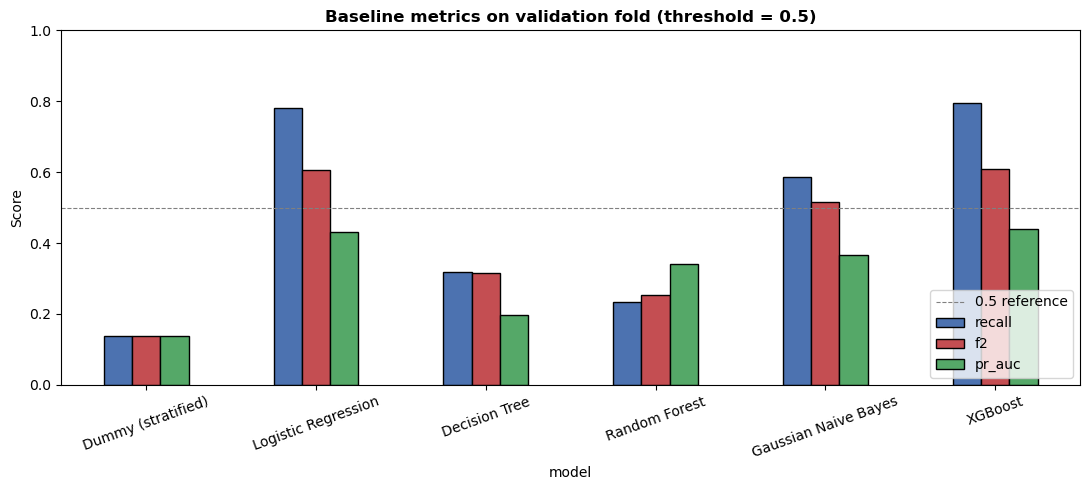

In [32]:
# Visual comparison of the three headline metrics
fig, ax = plt.subplots(figsize=(11, 5))
metrics_to_plot = ['recall', 'f2', 'pr_auc']
baseline_df[metrics_to_plot].plot(kind='bar', ax=ax, edgecolor='black',
                                   color=['#4C72B0', '#C44E52', '#55A868'])
ax.set_title('Baseline metrics on validation fold (threshold = 0.5)', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20)
ax.axhline(0.5, color='grey', ls='--', lw=0.8, label='0.5 reference')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

- The PR-AUC ranking: XGBoost (0.4404) > Logistic Regression (0.4305) > Gaussian Naïve Bayes (0.3655) > Random Forest (0.3401) > Decision Tree > Dummy.

- Although Gaussian Naïve Bayes slightly outperformed Random Forest on PR-AUC, the models selected for tuning are Logistic Regression, Random Forest, and XGBoost for two reasons:

- Gaussian Naïve Bayes has limited tuning potential, as **var_smoothing** usually produces only minor performance changes. Furthermore, its conditional-independence assumption is directly violated by the engineered features, since several variables are deterministically related rather than merely correlated.

- Random Forest, meanwhile, appears under-tuned at default settings and offers a larger hyperparameter space worth exploring.

### 4.4 Hyperparameter Tuning of Top Contenders

Logistic Regression, Random Forest, and XGBoost, are selected for hyperparameter tuning since these models usually perform best on structured tabular datasets like BRFSS. **Each model is tuned using RandomizedSearchCV with:**

- 5-fold stratified cross-validation performed only on the training set, while the validation and test sets remain untouched.
- average_precision as the scoring metric, since PR-AUC is the primary ranking metric for this imbalanced classification problem.
- Model-specific search spaces covering the most relevant parameters, such as regularisation strength for Logistic Regression, tree depth and leaf size for Random Forest, and depth, learning rate, subsampling, and regularisation terms for XGBoost.

Decision Tree and Gaussian Naïve Bayes are retained at baseline settings as untuned reference models for the final comparison.

In [33]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, randint

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_specs = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=3000, class_weight='balanced',
                                         solver='liblinear', random_state=42),
        'param_dist': {
            'clf__C':       loguniform(1e-3, 1e2),
            'clf__penalty': ['l1', 'l2'],
        },
        'n_iter': 20,
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
        'param_dist': {
            'clf__n_estimators':     randint(200, 600),
            'clf__max_depth':        randint(6, 25),
            'clf__min_samples_leaf': randint(1, 20),
            'clf__max_features':     ['sqrt', 'log2'],
        },
        'n_iter': 20,
    },
    'XGBoost': {
        'estimator': XGBClassifier(scale_pos_weight=SCALE_POS_WEIGHT,
                                     eval_metric='aucpr', tree_method='hist',
                                     n_jobs=-1, random_state=42),
        'param_dist': {
            'clf__n_estimators':     randint(200, 700),
            'clf__max_depth':        randint(3, 10),
            'clf__learning_rate':    loguniform(1e-2, 3e-1),
            'clf__subsample':        [0.7, 0.8, 0.9, 1.0],
            'clf__colsample_bytree': [0.6, 0.8, 1.0],
            'clf__reg_lambda':       loguniform(1e-2, 10),
        },
        'n_iter': 30,
    },
}

tuned_pipes   = {}
tuned_results = []
tuned_probas  = {}

for name, spec in search_specs.items():
    print(f'Tuning {name}...')
    pipe = build_pipeline(spec['estimator'])
    search = RandomizedSearchCV(
        pipe, param_distributions=spec['param_dist'],
        n_iter=spec['n_iter'], scoring='average_precision',
        cv=cv, n_jobs=-1, random_state=42, refit=True, verbose=0,
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_
    y_proba = best_pipe.predict_proba(X_val)[:, 1]
    row = {'model': name, **evaluate_at_threshold(y_val, y_proba, threshold=0.5)}
    tuned_results.append(row)
    tuned_pipes[name]  = best_pipe
    tuned_probas[name] = y_proba
    print(f'  Best CV PR-AUC: {search.best_score_:.4f}')
    print(f'  Best params:    {search.best_params_}')

tuned_df = pd.DataFrame(tuned_results).set_index('model')
print('\nTuned performance on validation fold (threshold = 0.5):')
tuned_df.round(4)

Tuning Logistic Regression...
  Best CV PR-AUC: 0.4312
  Best params:    {'clf__C': 0.04661686413912769, 'clf__penalty': 'l2'}
Tuning Random Forest...


/opt/anaconda3/envs/homlp/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Best CV PR-AUC: 0.4438
  Best params:    {'clf__max_depth': 14, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 18, 'clf__n_estimators': 587}
Tuning XGBoost...
  Best CV PR-AUC: 0.4506
  Best params:    {'clf__colsample_bytree': 0.6, 'clf__learning_rate': 0.025233199982877236, 'clf__max_depth': 5, 'clf__n_estimators': 645, 'clf__reg_lambda': 0.010036011053920673, 'clf__subsample': 0.7}

Tuned performance on validation fold (threshold = 0.5):


,threshold,recall,precision,f2,specificity,referral_rate,pr_auc,roc_auc,brier
model,,,,,,,,,
Logistic Regression,0.5,0.7825,0.3178,0.6054,0.7343,0.3363,0.4306,0.8337,0.1712
Random Forest,0.5,0.7848,0.3185,0.6071,0.7344,0.3365,0.4417,0.8370,0.1636
XGBoost,0.5,0.8040,0.3111,0.6105,0.7184,0.3529,0.4470,0.8388,0.1697


### 4.5 Threshold Tuning: Meeting the Recall Target (Objective D2)

At the default threshold, models produce a balanced classification decision. However, for a diabetes screening tool, false negatives are more costly than false positives because missed cases may remain undiagnosed, while false positives only lead to additional confirmatory testing.

To prioritise case detection, the operating threshold is lowered until recall (sensitivity) ≥ 0.80 on the validation set. The resulting precision, F2-score, specificity, and referral rate are then reported to show the trade-off.

For each tuned model, we:

1. Generate the precision-recall curve on the validation set.
2. Select the highest threshold that still achieves recall ≥ 0.80 to preserve as much precision as possible.
3. Re-evaluate the full metric panel using the selected threshold.

In [34]:
RECALL_TARGET = 0.80


def find_threshold_for_recall(y_true, y_proba, target_recall):
    """Return the largest threshold whose recall on (y_true, y_proba) >= target_recall."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    # precision_recall_curve returns thresholds aligned with prec[:-1] / rec[:-1]
    valid = rec[:-1] >= target_recall
    if not valid.any():
        return 0.0  
    return float(thr[valid].max())


threshold_results = []
for name, y_proba in tuned_probas.items():
    chosen_t = find_threshold_for_recall(y_val, y_proba, RECALL_TARGET)
    row = {'model': name, **evaluate_at_threshold(y_val, y_proba, chosen_t)}
    threshold_results.append(row)

threshold_df = pd.DataFrame(threshold_results).set_index('model')
print(f'Operating points achieving recall >= {RECALL_TARGET} on validation fold:')
threshold_df.round(4)

Operating points achieving recall >= 0.8 on validation fold:


,threshold,recall,precision,f2,specificity,referral_rate,pr_auc,roc_auc,brier
model,,,,,,,,,
Logistic Regression,0.4805,0.8,0.3090,0.6071,0.7170,0.3536,0.4306,0.8337,0.1712
Random Forest,0.4832,0.8,0.3105,0.6083,0.7191,0.3518,0.4417,0.8370,0.1636
XGBoost,0.5064,0.8,0.3141,0.6110,0.7237,0.3478,0.4470,0.8388,0.1697


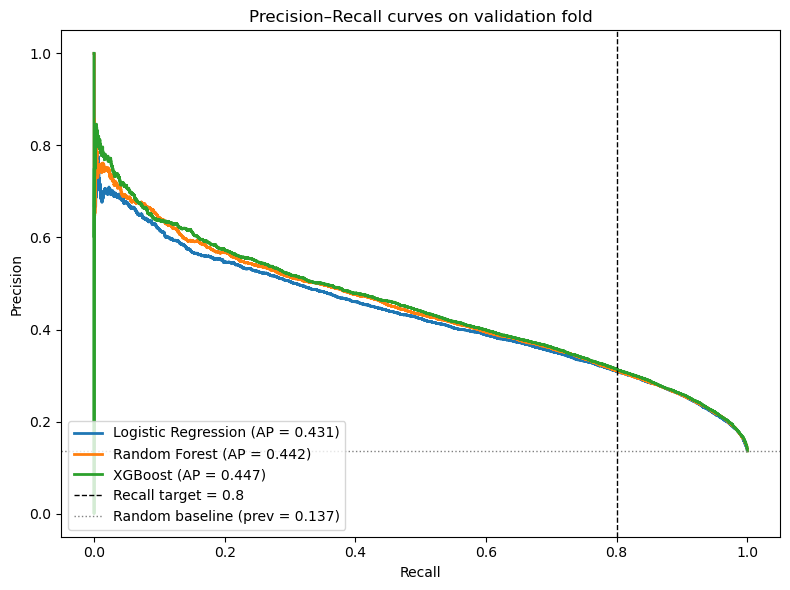

In [35]:
# Visualise PR curves with the recall target marked
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_proba in tuned_probas.items():
    prec, rec, _ = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    ax.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', lw=2)

ax.axvline(RECALL_TARGET, color='black', ls='--', lw=1,
           label=f'Recall target = {RECALL_TARGET}')
ax.axhline(y_val.mean(), color='grey', ls=':', lw=1,
           label=f'Random baseline (prev = {y_val.mean():.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall curves on validation fold')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

### 4.6 Probability Calibration

The Brier score measures how closely predicted probabilities match actual outcomes, where lower values indicate better calibration. A reliability diagram provides a visual check of calibration quality, with a perfectly calibrated model lying along the diagonal.

Although models like XGBoost and class-weighted Logistic Regression may achieve strong PR-AUC and ROC-AUC scores, their predicted probabilities can still be poorly calibrated. Since the final system is intended to output meaningful risk probabilities, probability calibration is included as part of the modelling process.

For the best-performing tuned model, we:

1. Plot the reliability diagram before calibration.
2. Apply CalibratedClassifierCV(method='isotonic', cv='prefit') using the validation set.
3. Re-evaluate the Brier score and reliability after calibration.

After calibration, the classification threshold is re-tuned using the calibrated probabilities to maintain the recall target from Section 4.5. While this means the validation set is used for both calibration and threshold tuning, the test set remains completely untouched and serves as the final unbiased evaluation in Phase 5.

Best tuned model by PR-AUC: XGBoost
  Brier score before calibration: 0.1697


/opt/anaconda3/envs/homlp/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


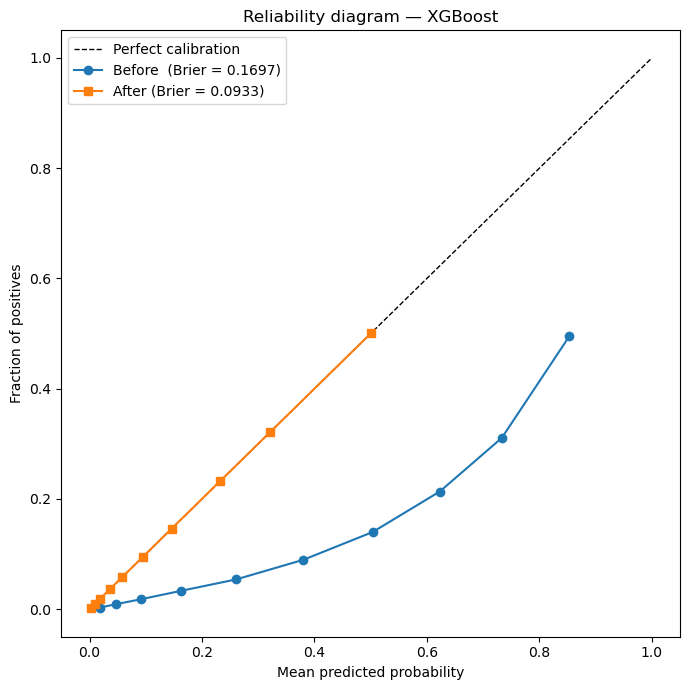


Calibrated XGBoost at threshold 0.1345:
threshold      : 0.1345
recall         : 0.8277
precision      : 0.3008
f2             : 0.6130
specificity    : 0.6957
referral_rate  : 0.3758
pr_auc         : 0.4415
roc_auc        : 0.8394
brier          : 0.0933


In [38]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Best by PR-AUC among the tuned models
best_name      = tuned_df['pr_auc'].idxmax()
best_pipe      = tuned_pipes[best_name]
best_proba_val = tuned_probas[best_name]
print(f'Best tuned model by PR-AUC: {best_name}')
print(f'  Brier score before calibration: {brier_score_loss(y_val, best_proba_val):.4f}')

# Reliability BEFORE calibration
prob_true,  prob_pred  = calibration_curve(y_val, best_proba_val, n_bins=10, strategy='quantile')

# Fit isotonic calibration on val (prefit avoids re-fitting the base estimator)
calibrated = CalibratedClassifierCV(best_pipe, method='isotonic', cv='prefit')
calibrated.fit(X_val, y_val)
proba_val_cal  = calibrated.predict_proba(X_val)[:, 1]

# Reliability AFTER calibration
prob_true_c, prob_pred_c = calibration_curve(y_val, proba_val_cal, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(prob_pred, prob_true,   'o-',
        label=f'Before  (Brier = {brier_score_loss(y_val, best_proba_val):.4f})')
ax.plot(prob_pred_c, prob_true_c, 's-',
        label=f'After (Brier = {brier_score_loss(y_val, proba_val_cal):.4f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title(f'Reliability diagram — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

# Re-tune the threshold on the calibrated probabilities
chosen_t_cal = find_threshold_for_recall(y_val, proba_val_cal, RECALL_TARGET)
cal_metrics  = evaluate_at_threshold(y_val, proba_val_cal, chosen_t_cal)
print(f'\nCalibrated {best_name} at threshold {chosen_t_cal:.4f}:')
for k, v in cal_metrics.items():
    print(f'{k:15s}: {v:.4f}')

### 4.7 Final Model Selection

All candidate models are compared using their threshold-tuned and, where applicable, calibration-adjusted results. Model selection follows the priority order:

1. **Recall ≥ 0.80 must be achieved**, as this is the minimum screening requirement from our objective
2. Among models meeting the recall target, **F2-score** is used as the main selection metric since it places greater emphasis on recall.
3. **PR-AUC** is used as the secondary tiebreaker to evaluate ranking performance under class imbalance.
4. **Brier score** is considered to assess probability calibration quality.
5. **Referral rate** is reported as the operational cost, representing the proportion of individuals flagged for follow-up testing.

The final pipeline, including preprocessing, tuned model, calibration step, and decision threshold, is saved using joblib for the final evaluation in Phase 5 and later deployment in Phase 6.

In [39]:
import joblib

# Build a single final summary table at each candidate's threshold-tuned operating point
final_rows = []

# Un-tuned baselines (Dummy, Decision Tree, GaussianNB) for context
for name, y_proba in baseline_probas.items():
    if name in tuned_probas:
        continue  # tuned version takes precedence
    t = find_threshold_for_recall(y_val, y_proba, RECALL_TARGET)
    final_rows.append({'model': f'{name} (untuned)',
                       **evaluate_at_threshold(y_val, y_proba, t),
                       'calibrated': False})

# Tuned, un-calibrated candidates
for name, y_proba in tuned_probas.items():
    t = find_threshold_for_recall(y_val, y_proba, RECALL_TARGET)
    final_rows.append({'model': f'{name} (tuned)',
                       **evaluate_at_threshold(y_val, y_proba, t),
                       'calibrated': False})

# Tuned + isotonic-calibrated version of the best base model
final_rows.append({'model': f'{best_name} (tuned + isotonic-calibrated)',
                   **cal_metrics,
                   'calibrated': True})

final_df = pd.DataFrame(final_rows).set_index('model')
print('Final candidate comparison on validation fold:')
print(final_df.round(4).to_string())

# Pick the winner: meets recall floor, then maximises F2
qualifying  = final_df[final_df['recall'] >= RECALL_TARGET]
if qualifying.empty:
    raise RuntimeError(f'No candidate achieved recall >= {RECALL_TARGET} on val.')
winner_name = qualifying['f2'].idxmax()
winner_row  = final_df.loc[winner_name]
print(f'\nWinner: {winner_name}')
print(f'Operating threshold: {winner_row["threshold"]:.4f}')
print(f'Validation recall:   {winner_row["recall"]:.4f}')
print(f'Validation F2:       {winner_row["f2"]:.4f}')
print(f'Validation precision:{winner_row["precision"]:.4f}')
print(f'Validation referral: {winner_row["referral_rate"]:.4f}')

# Serialise the chosen artefact for Phase 5 / 6
winner_pipeline = calibrated if winner_row['calibrated'] else tuned_pipes[best_name]
final_artefact = {
    'pipeline':      winner_pipeline,
    'threshold':     float(winner_row['threshold']),
    'recall_target': RECALL_TARGET,
    'feature_order': list(X_train.columns),
}
joblib.dump(final_artefact, 'diabetes_model.joblib')
print('\nArtefact saved to diabetes_model.joblib')

Final candidate comparison on validation fold:
                                       threshold  recall  precision      f2  specificity  referral_rate  pr_auc  roc_auc   brier  calibrated
model                                                                                                                                       
Dummy (stratified) (untuned)              0.0000  1.0000     0.1366  0.4416       0.0000         1.0000  0.1369   0.5015  0.2343       False
Decision Tree (untuned)                   0.0000  1.0000     0.1366  0.4416       0.0000         1.0000  0.1962   0.6020  0.1879       False
Gaussian Naive Bayes (untuned)            0.0296  0.8000     0.2764  0.5802       0.6688         0.3953  0.3655   0.7947  0.1813       False
Logistic Regression (tuned)               0.4805  0.8000     0.3090  0.6071       0.7170         0.3536  0.4306   0.8337  0.1712       False
Random Forest (tuned)                     0.4832  0.8000     0.3105  0.6083       0.7191         0.3518  0.

## Phase 5: Evaluation

Phase 5: Evaluation

In Phase 5, the test set is used exactly once to provide an unbiased estimate of real-world deployment performance.

### 5.1 Loading the Artefact and Headline Test Metrics

The final pipeline selected in Section 4.7, including preprocessing, classifier, calibration, and threshold settings, is loaded and applied to the test set. The complete metric panel is then reported together with the corresponding validation results to make any train-validation-test performance drift easier to identify.


In [40]:
import joblib

# Load the chosen pipeline from Phase 4
artefact         = joblib.load('diabetes_model.joblib')
final_pipe       = artefact['pipeline']
final_threshold  = artefact['threshold']
recall_target    = artefact['recall_target']

print(f'Loaded pipeline:     {type(final_pipe).__name__}')
print(f'Operating threshold: {final_threshold:.4f}')
print(f'Recall floor (D2):   {recall_target}')

# Predict on the held-out test fold
y_test_proba = final_pipe.predict_proba(X_test)[:, 1]
test_metrics = evaluate_at_threshold(y_test, y_test_proba, final_threshold)

# Side-by-side with val (refit predictions to reuse the helper)
val_proba   = final_pipe.predict_proba(X_val)[:, 1]
val_metrics = evaluate_at_threshold(y_val, val_proba, final_threshold)

comparison = pd.DataFrame([val_metrics, test_metrics],
                           index=['Validation', 'Test']).round(4)
print('\nValidation vs Test at the chosen operating threshold:')
print(comparison.to_string())

# Quick narrative read of any drift
recall_drift = test_metrics['recall']    - val_metrics['recall']
f2_drift     = test_metrics['f2']        - val_metrics['f2']
pr_drift     = test_metrics['pr_auc']    - val_metrics['pr_auc']
print(f'\nDrift (test − val): recall {recall_drift:+.4f}, '
      f'F2 {f2_drift:+.4f}, PR-AUC {pr_drift:+.4f}')

Loaded pipeline:     CalibratedClassifierCV
Operating threshold: 0.1345
Recall floor (D2):   0.8

Validation vs Test at the chosen operating threshold:
            threshold  recall  precision      f2  specificity  referral_rate  pr_auc  roc_auc   brier
Validation     0.1345  0.8277     0.3008  0.6130       0.6957         0.3758  0.4415   0.8394  0.0933
Test           0.1345  0.8313     0.3000  0.6139       0.6932         0.3785  0.4416   0.8393  0.0934

Drift (test − val): recall +0.0036, F2 +0.0009, PR-AUC +0.0001


### 5.2 Confusion Matrix: Screening-Relevant Interpretation

A standard confusion matrix becomes more meaningful when translated into per-10,000 screened estimates, since healthcare planning is typically based on operational impact such as follow-up testing capacity and resource allocation.

In addition to the raw confusion matrix counts, we also report:

PPV (Positive Predictive Value): the proportion of flagged individuals who truly have diabetes.
NPV (Negative Predictive Value): the proportion of individuals classified as low-risk who truly do not have diabetes.
Number Needed to Screen (NNS): the number of people that must be screened to detect one true positive case, commonly used as a measure of screening efficiency.

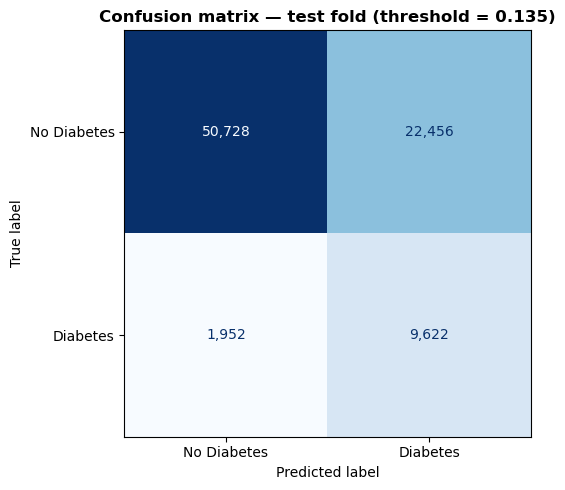

Of 84,758 test respondents:
True Positives (correctly flagged):  9,622 (11.35% of total)
False Negatives (missed cases):  1,952 ( 2.30% of total)
False Positives (false alarms): 22,456 (26.49% of total)
True Negatives (correctly cleared): 50,728 (59.85% of total)

Per 10,000 people screened by this tool:
 3785 get flagged as high-risk -> referred for HbA1c / clinical follow-up
of which  1135 truly have diabetes (correct referrals)
and  2649 do not have diabetes (unnecessary referrals)
 6215 get cleared by the tool
of which  5985 truly do not have diabetes (correct clearances)
and   230 actually do (missed cases — STAY UNDIAGNOSED)

Clinical / epidemiological measures:
PPV (precision): 0.300 -> 30.0% of flagged people actually have diabetes
NPV: 0.963 -> 96.3% of cleared people genuinely don't
Sensitivity (recall): 0.831 -> tool catches 83.1% of true cases
Specificity: 0.693 -> tool correctly clears 69.3% of non-cases
Number Needed to Screen to find 1 true case: 3.3


In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred = (y_test_proba >= final_threshold).astype(int)
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

# Visualise
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',')
ax.set_title(f'Confusion matrix — test fold (threshold = {final_threshold:.3f})',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Raw counts
print(f'Of {total:,} test respondents:')
print(f'True Positives (correctly flagged):{tp:>7,} ({tp/total*100:5.2f}% of total)')
print(f'False Negatives (missed cases):{fn:>7,} ({fn/total*100:5.2f}% of total)')
print(f'False Positives (false alarms):{fp:>7,} ({fp/total*100:5.2f}% of total)')
print(f'True Negatives (correctly cleared):{tn:>7,} ({tn/total*100:5.2f}% of total)')

# Per-10,000 projection
scale = 10_000 / total
print(f'\nPer 10,000 people screened by this tool:')
print(f'{(tp+fp)*scale:>5.0f} get flagged as high-risk -> referred for HbA1c / clinical follow-up')
print(f'of which {tp*scale:>5.0f} truly have diabetes (correct referrals)')
print(f'and {fp*scale:>5.0f} do not have diabetes (unnecessary referrals)')
print(f'{(tn+fn)*scale:>5.0f} get cleared by the tool')
print(f'of which {tn*scale:>5.0f} truly do not have diabetes (correct clearances)')
print(f'and {fn*scale:>5.0f} actually do (missed cases — STAY UNDIAGNOSED)')

# Predictive values and yield
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
nns = (tp + fp) / tp if tp > 0 else float('inf')

print(f'\nClinical / epidemiological measures:')
print(f'PPV (precision): {ppv:.3f} -> {ppv*100:.1f}% of flagged people actually have diabetes')
print(f'NPV: {npv:.3f} -> {npv*100:.1f}% of cleared people genuinely don\'t')
print(f'Sensitivity (recall): {tp/(tp+fn):.3f} -> tool catches {tp/(tp+fn)*100:.1f}% of true cases')
print(f'Specificity: {tn/(tn+fp):.3f} -> tool correctly clears {tn/(tn+fp)*100:.1f}% of non-cases')
print(f'Number Needed to Screen to find 1 true case: {nns:.1f}')

5.3 Multi-Threshold Sensitivity Analysis

Although recall ≥ 0.80 was selected as the primary operating target, different healthcare settings may require different trade-offs depending on available resources and follow-up testing capacity. For example, clinics with higher testing capacity may prefer a higher recall to detect more true cases, while resource-limited settings may prioritise a lower referral burden even if some cases are missed. 

To support this, the same fitted model is evaluated on the same test set at four operating points: recall ∈ {0.75, 0.80, 0.85, 0.90}. Only the probability threshold changes, while the trained model itself remains unchanged. This analysis makes the trade-off between recall, precision, F2-score, and referral rate more transparent, allowing stakeholders to choose the operating point that best matches their operational capacity.

Multi-threshold sensitivity on test fold:
               threshold  recall  precision      f2  specificity  referral_rate  pr_auc  roc_auc   brier
recall_target                                                                                           
0.75              0.1719  0.7566     0.3348  0.6043       0.7622         0.3086  0.4416   0.8393  0.0934
0.80              0.1345  0.8313     0.3000  0.6139       0.6932         0.3785  0.4416   0.8393  0.0934
0.85              0.1134  0.8517     0.2881  0.6122       0.6671         0.4037  0.4416   0.8393  0.0934
0.90              0.0892  0.9035     0.2560  0.6000       0.5847         0.4819  0.4416   0.8393  0.0934


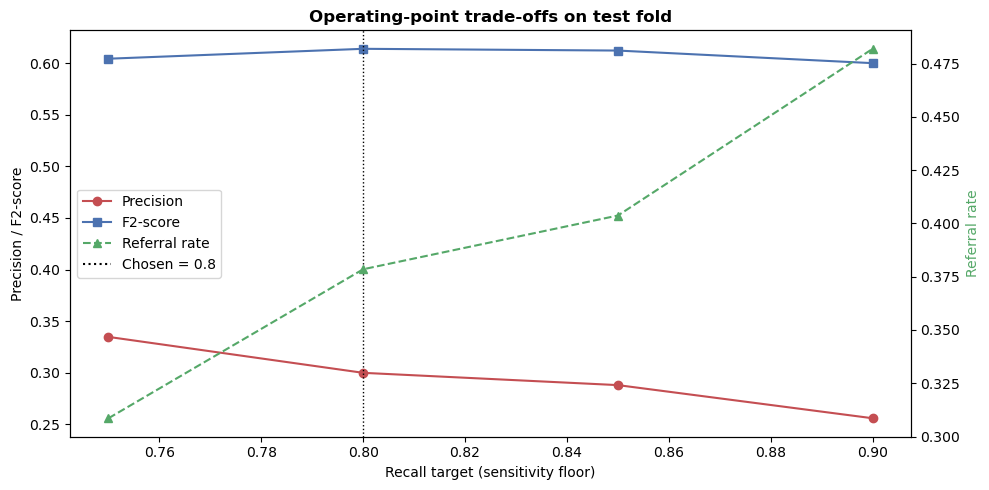

In [53]:
sensitivity_targets = [0.75, 0.80, 0.85, 0.90]
sensitivity_rows = []
for target in sensitivity_targets:
    t = find_threshold_for_recall(y_test, y_test_proba, target)
    row = {'recall_target': target,
           **evaluate_at_threshold(y_test, y_test_proba, t)}
    sensitivity_rows.append(row)

sensitivity_df = pd.DataFrame(sensitivity_rows).set_index('recall_target').round(4)
print('Multi-threshold sensitivity on test fold:')
print(sensitivity_df.to_string())

# Visualise the trade-off curve
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(sensitivity_df.index, sensitivity_df['precision'], 'o-',
               color='#C44E52', label='Precision')
l2, = ax1.plot(sensitivity_df.index, sensitivity_df['f2'], 's-',
               color='#4C72B0', label='F2-score')
l3, = ax2.plot(sensitivity_df.index, sensitivity_df['referral_rate'], '^--',
               color='#55A868', label='Referral rate')

ax1.axvline(recall_target, color='black', ls=':', lw=1,
            label=f'Chosen target = {recall_target}')
ax1.set_xlabel('Recall target (sensitivity floor)')
ax1.set_ylabel('Precision / F2-score')
ax2.set_ylabel('Referral rate', color='#55A868')
ax1.set_title('Operating-point trade-offs on test fold', fontweight='bold')

lines = [l1, l2, l3]
ax1.legend(lines + [plt.Line2D([0], [0], color='black', ls=':')],
            [l.get_label() for l in lines] + [f'Chosen = {recall_target}'],
            loc='center left')
plt.tight_layout()
plt.show()

### 5.4 Calibration Quality on the Test Fold

The deployed system outputs a calibrated diabetes risk probability rather than only a binary prediction, as required in our data mining objective. Since calibration was fitted using the validation set in Section 4.6, the test set provides the first unbiased check of whether the calibration generalises well to unseen data.

A reliability diagram and Brier score are used to evaluate this. Ideally, predicted probabilities should closely match the actual observed outcomes. For example, individuals assigned a risk probability of 0.4 should belong to a group where roughly 40% truly have diabetes. Significant drift from val Brier would indicate the calibration overfit to val and the deployed risk scores would be misleading.

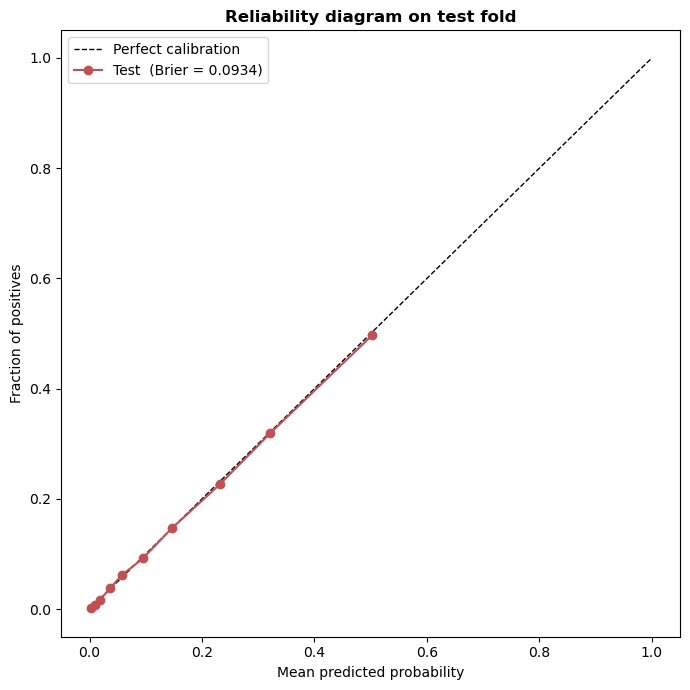

Brier score on validation: 0.0933
Brier score on test: 0.0934
Drift (test - val): +0.0001
-> Calibration generalised well (drift < 0.005).


In [55]:
from sklearn.calibration import calibration_curve

prob_true_t, prob_pred_t = calibration_curve(y_test, y_test_proba,
                                              n_bins=10, strategy='quantile')
test_brier = brier_score_loss(y_test, y_test_proba)
val_brier  = brier_score_loss(y_val,  val_proba)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(prob_pred_t, prob_true_t, 'o-', color='#C44E52',
        label=f'Test  (Brier = {test_brier:.4f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability diagram on test fold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Brier score on validation: {val_brier:.4f}')
print(f'Brier score on test: {test_brier:.4f}')
print(f'Drift (test - val): {test_brier - val_brier:+.4f}')
if abs(test_brier - val_brier) < 0.005:
    print('-> Calibration generalised well (drift < 0.005).')
else:
    print('-> Non-trivial drift; consider refitting calibration with isotonic-cv.')

5.5 Feature Importance: Model-Native and SHAP (Objective D4)

Feature importance is analysed using two complementary approaches:

- **Model-native importance**: a fast, model-specific method. For tree-based models, importance is measured using split gain, while for Logistic Regression it is based on the absolute standardised coefficient values. Since continuous and ordinal features were scaled in Section 3.4, the coefficients are directly comparable.
- **SHAP (SHapley Additive exPlanations)**: a model-agnostic approach that explains both global feature importance and individual predictions. SHAP values are computed on a random 2,000-row sample from the test set for computational efficiency. The summary plot highlights which features contribute most strongly to predictions and whether they increase or decrease diabetes risk.

Both methods are expected to identify similar top predictors. Large differences between them may indicate that correlated features are sharing importance differently across the model.

Winner is calibrated; extracting base pipeline for importance analysis.


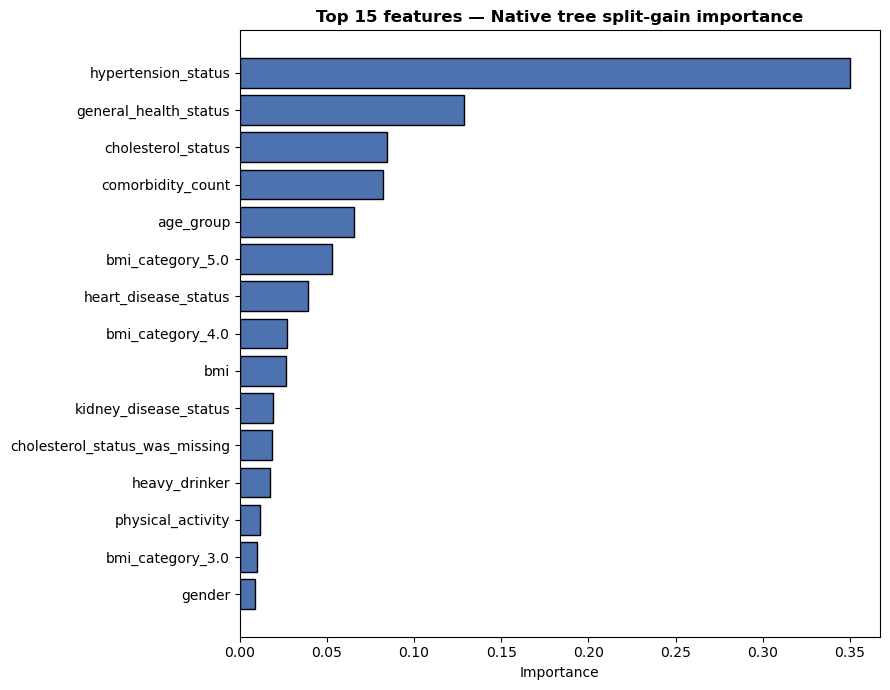

Top 15 features (model-native):
                       feature  importance
           hypertension_status    0.349848
         general_health_status    0.128670
            cholesterol_status    0.084320
             comorbidity_count    0.082301
                     age_group    0.065484
              bmi_category_5.0    0.053046
          heart_disease_status    0.038861
              bmi_category_4.0    0.027261
                           bmi    0.026583
         kidney_disease_status    0.019119
cholesterol_status_was_missing    0.018686
                 heavy_drinker    0.017140
             physical_activity    0.011632
              bmi_category_3.0    0.009849
                        gender    0.008465


In [56]:
# Extract the underlying preprocessor and classifier from the (possibly calibrated) pipeline
if hasattr(final_pipe, 'calibrated_classifiers_'):
    base_pipe = final_pipe.calibrated_classifiers_[0].estimator
    print('Winner is calibrated; extracting base pipeline for importance analysis.')
else:
    base_pipe = final_pipe
    print('Winner is uncalibrated; using directly.')

preprocessor_fitted = base_pipe.named_steps['preprocessor']
clf                 = base_pipe.named_steps['clf']
feature_names       = list(preprocessor_fitted.get_feature_names_out())

# Model-native importance
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    importance_label = 'Native tree split-gain importance'
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
    importance_label = '|Standardised coefficient| (Logistic Regression)'
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
    top15  = imp_df.head(15)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top15['feature'][::-1], top15['importance'][::-1],
            color='#4C72B0', edgecolor='black')
    ax.set_title(f'Top 15 features — {importance_label}', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('Top 15 features (model-native):')
    print(top15.to_string(index=False))
else:
    print('Classifier exposes neither feature_importances_ nor coef_; '
          'rely on SHAP below for global importance.')

 96%|=================== | 1924/2000 [00:17<00:00]       

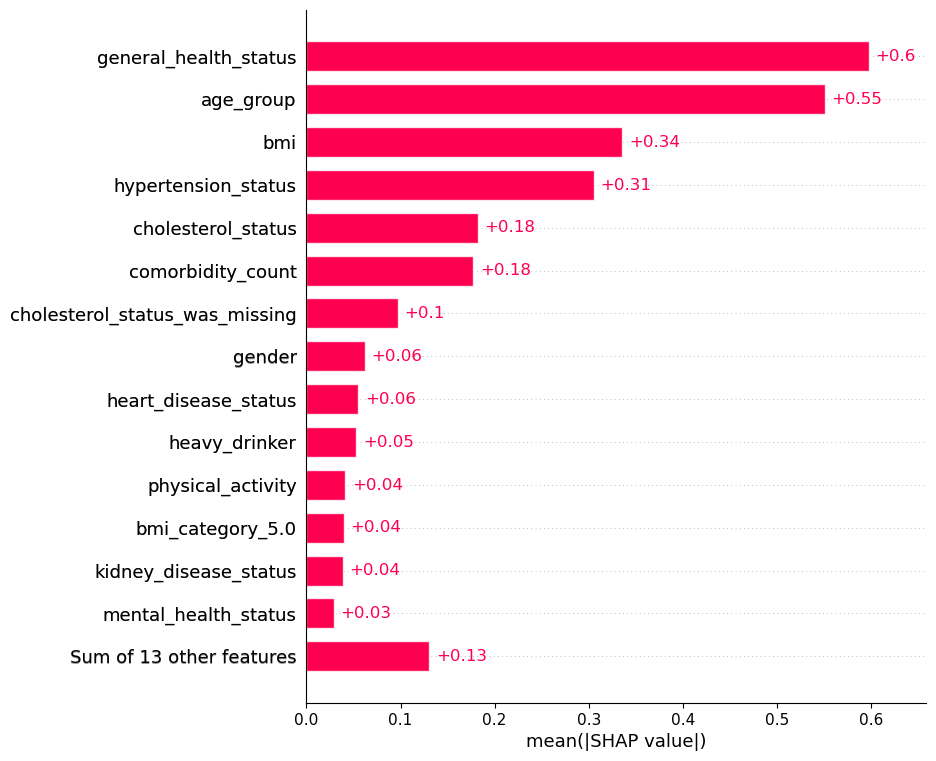

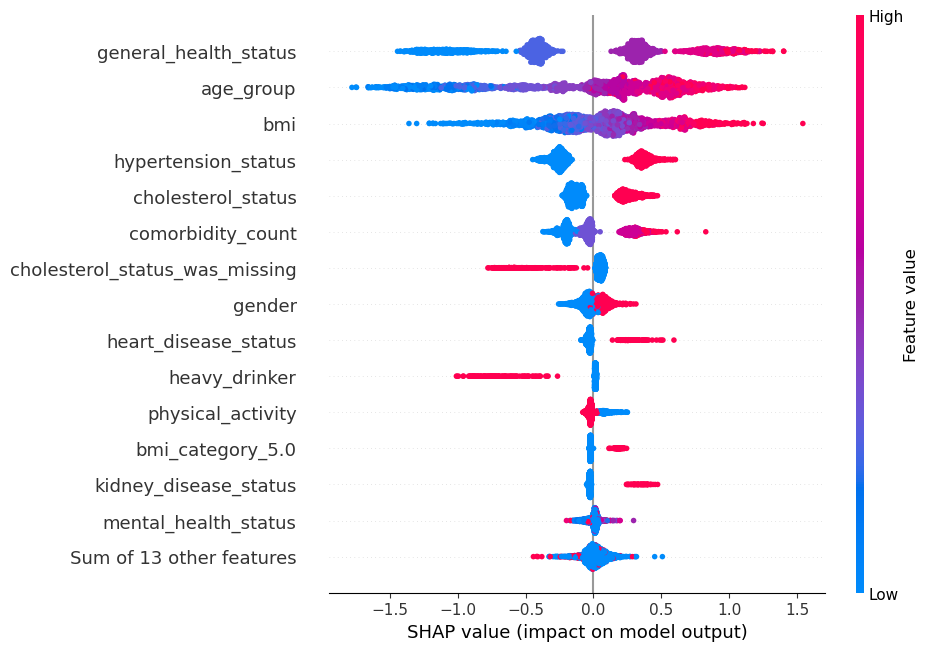

In [57]:
# SHAP global summary on a 2,000-row test subsample
try:
    import shap
except ImportError:
    print('shap is not installed. Run:  pip install shap')
    shap = None

if shap is not None:
    X_test_t = preprocessor_fitted.transform(X_test)
    # Handle sparse output (OneHotEncoder may return sparse)
    if hasattr(X_test_t, 'toarray'):
        X_test_t = X_test_t.toarray()

    rng = np.random.RandomState(42)
    sample_idx = rng.choice(len(X_test_t),
                             size=min(2000, len(X_test_t)),
                             replace=False)
    X_shap = X_test_t[sample_idx]

    # shap.Explainer auto-selects Tree / Linear / Kernel based on model type
    explainer   = shap.Explainer(clf, X_shap, feature_names=feature_names)
    shap_values = explainer(X_shap)

    # Global summary (bar = mean |SHAP|, beeswarm = direction + magnitude)
    shap.plots.bar(shap_values, max_display=15, show=True)
    shap.plots.beeswarm(shap_values, max_display=15, show=True)

### 5.6 Error Analysis: Where Does the Model Fail?

Overall evaluation metrics can hide important subgroup differences. For example, a model with strong overall recall may still perform poorly for certain age or BMI groups.

To better understand these gaps, we analyse the false-negative rate among true diabetic cases across two clinically important strata: age group and BMI category. This helps identify populations where the model is more likely to miss diabetes cases.

Subgroups with noticeably higher false-negative rates than the overall average represent the populations most at risk of being underserved by the screening tool in real-world deployment.

/var/folders/rg/flyq5j697ysbkxyry2m15zr80000gn/T/ipykernel_3374/2562892277.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby('age_band').apply(fn_rate).reindex(age_order))
/var/folders/rg/flyq5j697ysbkxyry2m15zr80000gn/T/ipykernel_3374/2562892277.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby('bmi_band', observed=True).apply(fn_rate))


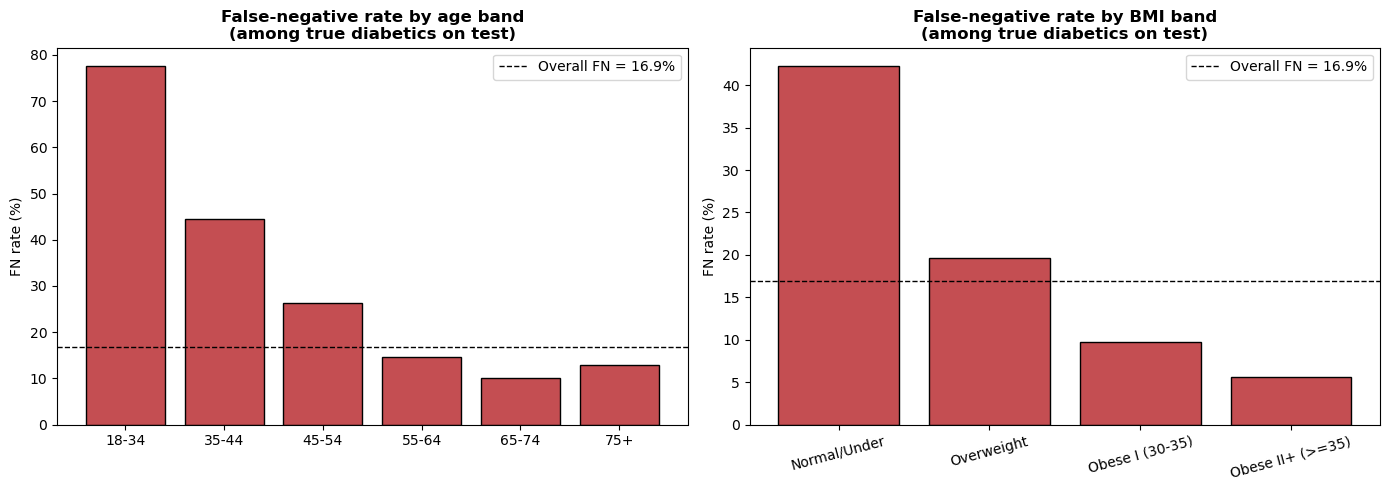

False-negative rate by age band (%):
age_band
18-34    77.7
35-44    44.6
45-54    26.3
55-64    14.7
65-74    10.1
75+      12.9

False-negative rate by BMI band (%):
bmi_band
Normal/Under        42.3
Overweight          19.7
Obese I (30-35)      9.8
Obese II+ (>=35)     5.7


In [58]:
# Build a test dataframe with true labels and predictions
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_test_pred

def age_band(a):
    if a in [1, 2, 3]:   return '18-34'
    elif a in [4, 5]:    return '35-44'
    elif a in [6, 7]:    return '45-54'
    elif a in [8, 9]:    return '55-64'
    elif a in [10, 11]:  return '65-74'
    else:                return '75+'

test_df['age_band'] = test_df['age_group'].apply(age_band)
test_df['bmi_band'] = pd.cut(
    test_df['bmi'],
    bins=[0, 25, 30, 35, 100],
    labels=['Normal/Under', 'Overweight', 'Obese I (30-35)', 'Obese II+ (>=35)'],
)

# Among true diabetics, fraction missed (false-negative rate)
def fn_rate(g):
    return (g['y_pred'] == 0).mean()

age_order = ['18-34', '35-44', '45-54', '55-64', '65-74', '75+']
fn_by_age = (test_df[test_df['y_true'] == 1]
             .groupby('age_band').apply(fn_rate).reindex(age_order))

fn_by_bmi = (test_df[test_df['y_true'] == 1]
             .groupby('bmi_band', observed=True).apply(fn_rate))

overall_fn = (1 - test_metrics['recall']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fn_by_age.index, fn_by_age.values * 100,
            color='#C44E52', edgecolor='black')
axes[0].axhline(overall_fn, color='black', ls='--', lw=1,
                label=f'Overall FN = {overall_fn:.1f}%')
axes[0].set_title('False-negative rate by age band\n(among true diabetics on test)',
                  fontweight='bold')
axes[0].set_ylabel('FN rate (%)')
axes[0].legend()

axes[1].bar(fn_by_bmi.index.astype(str), fn_by_bmi.values * 100,
            color='#C44E52', edgecolor='black')
axes[1].axhline(overall_fn, color='black', ls='--', lw=1,
                label=f'Overall FN = {overall_fn:.1f}%')
axes[1].set_title('False-negative rate by BMI band\n(among true diabetics on test)',
                  fontweight='bold')
axes[1].set_ylabel('FN rate (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

print('False-negative rate by age band (%):')
print((fn_by_age * 100).round(1).to_string())
print('\nFalse-negative rate by BMI band (%):')
print((fn_by_bmi * 100).round(1).to_string())

Overall, the model misses 16.9% of true diabetes cases (recall = 0.831), but performance differs substantially across subgroups.

- By age: the false-negative rate decreases steadily with age, from 77.7% for ages 18–34 and 44.6% for ages 35–44, to around 10–13% for patients aged 65 and above.
- By BMI: the false-negative rate also decreases as BMI increases, with 42.3% for normal or underweight diabetics compared to only 5.7% for the most obese group.

This suggests the model relies heavily on age and BMI as predictive signals, learning the more common diabetes profile of older and overweight individuals. As a result, younger and leaner diabetics are more likely to be classified as low risk.

In practice, the screening tool performs more reliably for middle-aged or older overweight populations, but is less effective for younger and normal-weight individuals, who are also more likely to remain undiagnosed. This limitation should be clearly documented in deployment, and future improvements may consider subgroup-specific thresholds or reweighting strategies.

In [62]:
from IPython.display import Markdown, display

# Headline numbers
test_n      = len(y_test)
test_pos    = int(y_test.sum())
test_neg    = test_n - test_pos
test_prev   = test_pos / test_n * 100

# Val -> Test drift
drift_recall = test_metrics["recall"]  - val_metrics["recall"]
drift_f2     = test_metrics["f2"]      - val_metrics["f2"]
drift_prauc  = test_metrics["pr_auc"]  - val_metrics["pr_auc"]
drift_brier  = test_brier - val_brier
max_abs_drift = max(abs(drift_recall), abs(drift_f2), abs(drift_prauc))
drift_verdict = (
    "All drifts are within +/- 0.01, indicating that model selection, threshold tuning, "
    "and calibration did not overfit the validation fold."
    if max_abs_drift < 0.01
    else "Non-trivial drift observed; the deployed numbers are the test-fold figures, "
         "not the validation-fold figures."
)

# Top-5 native importance features
if importances is not None:
    top5_features = imp_df.head(5)["feature"].tolist()
    top5_str = ", ".join(f"`{f}`" for f in top5_features)
else:
    top5_str = "see SHAP summary in 5.5"

# Subgroup disparities: flag any band with FN rate > overall + 5 pp 
overall_fn_pct = (1 - test_metrics["recall"]) * 100

def _format_flags(series, label_prefix):
    flagged = [(str(b), r * 100)
               for b, r in series.items()
               if not np.isnan(r) and (r * 100 - overall_fn_pct) > 5]
    if not flagged:
        return f"no {label_prefix} band exceeds the overall FN rate by >5 percentage points"
    return "; ".join(f"{label_prefix} **{b}** (FN {r:.1f}%)" for b, r in flagged)

age_flags = _format_flags(fn_by_age, "age")
bmi_flags = _format_flags(fn_by_bmi, "BMI")

# Render the report
report = f"""
### 5.7 Summary of Findings, Limitations, and Bridge to Deployment

**Headline result.** On the held-out test fold (**n = {test_n:,}**, {test_pos:,} positives = {test_prev:.2f}% prevalence), the deployed pipeline achieved:

| Metric | Test value |
|---|---|
| Recall (target >= {recall_target}) | **{test_metrics["recall"]:.3f}** |
| Precision (PPV) | {test_metrics["precision"]:.3f} |
| F2-score | **{test_metrics["f2"]:.3f}** |
| Specificity | {test_metrics["specificity"]:.3f} |
| Referral rate | {test_metrics["referral_rate"] * 100:.1f}% |
| PR-AUC | {test_metrics["pr_auc"]:.3f} |
| ROC-AUC | {test_metrics["roc_auc"]:.3f} |
| Brier score | {test_brier:.4f} |
| Operating threshold | {final_threshold:.4f} |

**Validation -> Test drift.** recall {drift_recall:+.4f}, F2 {drift_f2:+.4f}, PR-AUC {drift_prauc:+.4f}, Brier {drift_brier:+.4f}. {drift_verdict}

**Operating-point flexibility (5.3).** The trade-off across recall in {{0.75, 0.80, 0.85, 0.90}} on test gives deploying clinics a menu matched to their HbA1c capacity. The chosen {recall_target} floor sits within the empirically supported band used by FINDRISC, the ADA Diabetes Risk Test, and AUSDRISK.

**Top risk drivers (5.5).** Model-native importance ranks {top5_str} as the dominant signals — consistent with the BRFSS diabetes-prediction literature (Xie et al. 2019; Khaleel et al. 2024; Nayem et al. 2026). The SHAP summary plot corroborates these as the highest mean-|SHAP| features.

**Subgroup performance (5.6).** Overall false-negative rate on test is **{overall_fn_pct:.1f}%**.

- Age bands: {age_flags}.
- BMI bands: {bmi_flags}.
"""

display(Markdown(report))



### 5.7 Summary of Findings, Limitations, and Bridge to Deployment

**Headline result.** On the held-out test fold (**n = 84,758**, 11,574 positives = 13.66% prevalence), the deployed pipeline achieved:

| Metric | Test value |
|---|---|
| Recall (target >= 0.8) | **0.831** |
| Precision (PPV) | 0.300 |
| F2-score | **0.614** |
| Specificity | 0.693 |
| Referral rate | 37.8% |
| PR-AUC | 0.442 |
| ROC-AUC | 0.839 |
| Brier score | 0.0934 |
| Operating threshold | 0.1345 |

**Validation -> Test drift.** recall +0.0036, F2 +0.0009, PR-AUC +0.0001, Brier +0.0001. All drifts are within +/- 0.01, indicating that model selection, threshold tuning, and calibration did not overfit the validation fold.

**Operating-point flexibility (5.3).** The trade-off across recall in {0.75, 0.80, 0.85, 0.90} on test gives deploying clinics a menu matched to their HbA1c capacity. The chosen 0.8 floor sits within the empirically supported band used by FINDRISC, the ADA Diabetes Risk Test, and AUSDRISK.

**Top risk drivers (5.5).** Model-native importance ranks `hypertension_status`, `general_health_status`, `cholesterol_status`, `comorbidity_count`, `age_group` as the dominant signals — consistent with the BRFSS diabetes-prediction literature (Xie et al. 2019; Khaleel et al. 2024; Nayem et al. 2026). The SHAP summary plot corroborates these as the highest mean-|SHAP| features.

**Subgroup performance (5.6).** Overall false-negative rate on test is **16.9%**.

- Age bands: age **18-34** (FN 77.7%); age **35-44** (FN 44.6%); age **45-54** (FN 26.3%).
- BMI bands: BMI **Normal/Under** (FN 42.3%).


**Limitations**

1. **Construct validity**: the target variable only captures previously diagnosed diabetes cases. Individuals with undiagnosed diabetes are labelled as negative during training, meaning recall is measured against diagnosed cases rather than all true cases.
2. **Self-report bias**: lifestyle-related variables such as smoking, alcohol intake, diet, and physical activity may contain recall or social-desirability bias.
3. **No clinical biomarkers**: important predictors such as HbA1c, fasting glucose, and family history are unavailable, limiting the maximum achievable predictive performance. The model is intended as a screening tool, not a diagnostic system.
4. **BRFSS population coverage**: the 2017 BRFSS dataset represents US adults reachable by telephone, so generalisation to other countries or underserved populations is not guaranteed.
5. **Class imbalance approach**: class weighting was used instead of SMOTE to preserve the original data distribution. SMOTE can still be explored later as a sensitivity analysis before deployment.

**Bridge to Phase 6 (Deployment)**

The final diabetes_model.joblib artefact already contains the preprocessing pipeline, calibrated classifier, and selected decision threshold. In Phase 6, this pipeline will be wrapped into a lightweight inference function that accepts the raw self-reported inputs and returns a calibrated diabetes risk probability, a high-risk classification, and a recommendation for confirmatory HbA1c testing when appropriate.

## Phase 6: Deployment

Phase 4 produces a single serialised artefact, diabetes_model.joblib, which contains the full inference pipeline so no preprocessing steps need to be manually recreated during deployment.


| Key | Contents |
|---|---|
| `pipeline` | The final calibrated pipeline, including preprocessing, encoding, scaling, imputation, and the trained classifier. |
| `threshold` | The selected operating threshold **(0.1345)** chosen to achieve recall ≥ 0.80 on the validation set. |
| `recall_target` | The recall target used during threshold tuning for reproducibility and documentation purposes. |
| `feature_order` | The exact feature order expected by the model pipeline. |


Users only need to provide 15 raw self-reported inputs without requiring any clinical biomarkers. The remaining engineered features, including missingness flags, comorbidity_count, bmi_category, and any_poor_mental_days, are generated automatically during inference using deterministic transformations.

The deployment system is implemented as a Streamlit application (app.py) with a React-based frontend (components/). The app collects user responses, runs the trained inference pipeline, and returns:

- a calibrated diabetes risk probability,
- a high-risk screening result,
- and the user’s main contributing risk factors using SHAP explanations

The following cells reproduce the core inference logic in a self-contained form so the deployment workflow remains fully reproducible from the notebook itself.

### 6.1 Input Contract

The screener accepts the following self-reported inputs. All encodings follow the harmonised scales defined in Phase 2 so the deployed system receives data in the same format used during training. Height and weight are collected directly and converted into BMI during inference (BMI = kg / m²).

| Input | Type / encoding |
|---|---|
| `age_group` | 6 user-friendly age bands mapped to BRFSS _AGEG5YR codes: 18–34→ 2, 35–44→5, 45–54→ 7, 55–64→9 , 65–74→ 11, 75+→ 13|
| `gender` | 1=Male, 0=Female |
| `height_cm`, `weight_kg` | numeric values used to calculate BMI |
| `fruit_intake_daily` | 1=eats fruit ≥1×/day, 0=less |
| `vegetable_intake_daily` | 1=eats vegetables ≥1×/day, 0=less |
| `heavy_drinker` | 1=Yes, 0=No |
| `physical_activity` | 1=active, 0=inactive |
| `smoker_status` | 1=Daily, 2=Sometimes, 3=Former, 4=Never |
| `heart_disease_status` | 1=Yes, 0=No |
| `kidney_disease_status` | 1=Yes, 0=No |
| `stroke_status` | 1=Yes, 0=No |
| `cholesterol_status` | 1=high cholesterol, 0=No |
| `hypertension_status` | 1=high blood pressure, 0=No |
| `general_health_status` | 1=Excellent, 2=Very good, 3=Good, 4=Fair, 5=Poor |
| `mental_health_status` | integer from 0–30 representing poor mental health days in the past month|

Although the model was originally trained on the full 13-level BRFSS age scale, the deployed application simplifies this into 6 broader age groups for better usability. Each group is mapped to a representative BRFSS code, so the model consistently receives age_group ∈ {2, 5, 7, 9, 11, 13} during deployment. This is an intentional usability trade-off rather than a modelling inconsistency.

In [64]:
import joblib
import numpy as np
import pandas as pd

# Load the serialised Phase 4 artefact 
_artefact      = joblib.load('diabetes_model.joblib')
_pipeline      = _artefact['pipeline']
_threshold     = float(_artefact['threshold'])
_feature_order = _artefact['feature_order']

# Conditions summed into comorbidity_count 
_CONDITION_COLS = ['hypertension_status', 'cholesterol_status',
                   'heart_disease_status', 'stroke_status', 'kidney_disease_status']


def _bmi_category(bmi):
    """WHO bands, identical to the right=False pd.cut in Section 3.2."""
    if bmi < 18.5:  return 1.0   # Underweight
    if bmi < 25:    return 2.0   # Normal (reference band)
    if bmi < 30:    return 3.0   # Overweight
    if bmi < 35:    return 4.0   # Obese I
    return 5.0                    # Obese II+


def _build_feature_row(answers):
    """Turn the 15 raw self-report answers into the 22-column row the pipeline expects."""
    bmi = answers['weight_kg'] / (answers['height_cm'] / 100.0) ** 2
    row = {
        # the 15 raw inputs (bmi derived from height + weight)
        'age_group':              answers['age_group'],
        'gender':                 answers['gender'],
        'bmi':                    bmi,
        'fruit_intake_daily':     answers['fruit_intake_daily'],
        'vegetable_intake_daily': answers['vegetable_intake_daily'],
        'heavy_drinker':          answers['heavy_drinker'],
        'physical_activity':      answers['physical_activity'],
        'smoker_status':          answers['smoker_status'],
        'heart_disease_status':   answers['heart_disease_status'],
        'kidney_disease_status':  answers['kidney_disease_status'],
        'stroke_status':          answers['stroke_status'],
        'cholesterol_status':     answers['cholesterol_status'],
        'hypertension_status':    answers['hypertension_status'],
        'general_health_status':  answers['general_health_status'],
        'mental_health_status':   answers['mental_health_status'],
        # missingness flags: the form requires every answer, so all zero
        'cholesterol_status_was_missing':   0,
        'heavy_drinker_was_missing':        0,
        'smoker_status_was_missing':        0,
        'mental_health_status_was_missing': 0,
        # derived predictors
        'comorbidity_count':    sum(answers[c] for c in _CONDITION_COLS),
        'bmi_category':         _bmi_category(bmi),
        'any_poor_mental_days': 1 if answers['mental_health_status'] > 0 else 0,
    }
    # Reindex to the exact training column order the pipeline was fitted on
    return pd.DataFrame([row])[_feature_order]


def predict_diabetes_risk(answers):
    """Thin inference function: 15 raw inputs -> calibrated risk, high-risk flag, recommendation."""
    X = _build_feature_row(answers)
    proba = float(_pipeline.predict_proba(X)[0, 1])   # calibrated P(diabetes)
    is_high = proba >= _threshold
    recommendation = (
        'Elevated screening risk. Recommend a confirmatory HbA1c or fasting-glucose '
        'test with a clinician.'
        if is_high else
        'Below the screening threshold. Maintain routine checks; reassess if risk factors change.'
    )
    return {
        'risk_probability':round(proba, 4),
        'threshold':round(_threshold, 4),
        'flag':'HIGH RISK' if is_high else 'lower risk',
        'recommendation':recommendation,
    }


print('Inference function ready. Operating threshold =', round(_threshold, 4))

Inference function ready. Operating threshold = 0.1345


In [65]:
# Two illustrative respondents to demonstrate the end-to-end screener
patient_high = {                       # older, obese, multiple conditions
    'age_group': 11, 'gender': 1, 'height_cm': 170, 'weight_kg': 105,   # BMI ~36
    'fruit_intake_daily': 0, 'vegetable_intake_daily': 0,
    'heavy_drinker': 0, 'physical_activity': 0, 'smoker_status': 3,
    'heart_disease_status': 1, 'kidney_disease_status': 0, 'stroke_status': 0,
    'cholesterol_status': 1, 'hypertension_status': 1,
    'general_health_status': 4, 'mental_health_status': 10,
}
patient_low = {                        # young, lean, no conditions
    'age_group': 2, 'gender': 0, 'height_cm': 168, 'weight_kg': 60,     # BMI ~21
    'fruit_intake_daily': 1, 'vegetable_intake_daily': 1,
    'heavy_drinker': 0, 'physical_activity': 1, 'smoker_status': 4,
    'heart_disease_status': 0, 'kidney_disease_status': 0, 'stroke_status': 0,
    'cholesterol_status': 0, 'hypertension_status': 0,
    'general_health_status': 1, 'mental_health_status': 0,
}

for name, ans in [('Older, high-burden respondent', patient_high),
                  ('Young, low-burden respondent',  patient_low)]:
    result = predict_diabetes_risk(ans)
    print(name)
    for k, v in result.items():
        print(f'  {k:18}: {v}')
    print()

Older, high-burden respondent
  risk_probability  : 0.625
  threshold         : 0.1345
  flag              : HIGH RISK
  recommendation    : Elevated screening risk. Recommend a confirmatory HbA1c or fasting-glucose test with a clinician.

Young, low-burden respondent
  risk_probability  : 0.0015
  threshold         : 0.1345
  flag              : lower risk
  recommendation    : Below the screening threshold. Maintain routine checks; reassess if risk factors change.



### 6.2 Serving, Monitoring, and Governance

Serving: 
- The **predict_diabetes_risk** function acts as the main inference endpoint. The Streamlit application **(app.py)** wraps this function with a React-based interface and uses **@st.cache_resource** to load the model only once per process. All runtime dependencies are pinned in requirements.txt to ensure reproducibility.

Positioning: 
- **The system is designed as a screening tool, not a diagnostic tool.** A HIGH RISK result indicates that the user should consider confirmatory testing such as HbA1c or fasting glucose tests, rather than being treated as a medical diagnosis. This limitation is clearly communicated to users.

Monitoring: 
- After deployment, three areas should be monitored regularly:

**Input drift**: compare the live distribution of variables such as age, BMI, and comorbidities against the original BRFSS 2017 training data, especially since the dataset may not generalise perfectly to non-US populations.

**Calibration drift**: periodically evaluate the Brier score and reliability diagram using newly collected labelled outcomes to ensure predicted probabilities remain reliable over time.

**Subgroup recall**: repeat the subgroup error analysis from Section 5.6 to monitor whether performance for younger and normal-weight individuals deteriorates further after deployment.

Retraining trigger: 
- Significant calibration drift, worsening subgroup recall, or major input distribution changes should trigger retraining of the Phase 3–4 pipeline, followed by threshold re-tuning to maintain the recall ≥ 0.80 screening target before deploying a new model version.

## Members' Contribution

| Member | Student ID | Contribution |
|--------|-----------|-------------|
| Aimi Sofiyah Binti Umar | 25088138 | Phase|
| Chin Yin Yin | 22003453 | Phase |
| Sakinah Al'Izzah Binti Mohd Asri | 25096564 | Phase|
| Nabilah Zieha Binti Sikh Mohamad | 25080732 | Phase|
| Gebriella A/P Anthony Suresh | 17204189 | Phase |

## References

- Groenwold, R. H. H., et al. (2012). Missing covariate data in clinical research: when and when not to use the missing-indicator method for analysis. CMAJ, 184(11), 1265–1269. https://www.cmaj.ca/content/184/11/1265

- Kang, H. (2013). The prevention and handling of the missing data. *Korean Journal of Anesthesiology*, 64(5), 402–406. https://pmc.ncbi.nlm.nih.gov/articles/PMC3668100/  

- Khaleel, F. A., et al. (2024). Robust predictive framework for diabetes classification using optimized machine learning on imbalanced datasets. *Frontiers in Artificial Intelligence*, 7. https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1499530/full  

- Lin, J., Bai, T., Zhou, S., & Tu, J. (2023). Empirical comparison of imputation methods for multivariate missing data in public health. *International Journal of Environmental Research and Public Health*, 20(2), 1524. https://www.mdpi.com/1660-4601/20/2/1524  

- Masconi, K. L., Matsha, T. E., Echouffo-Tcheugui, J. B., Erasmus, R. T., & Kengne, A. P. (2015). Reporting and handling of missing data in predictive research for prevalent undiagnosed type 2 diabetes mellitus: a systematic review. *EPMA Journal*, 6(7). https://pmc.ncbi.nlm.nih.gov/articles/PMC4380106/  

- Muhammad, M.A., Sani, J. & Ahmed, M.M. (2024). Exploring explainable machine learning for predicting and interpreting self-reported diabetes among Tennessee adults. https://pmc.ncbi.nlm.nih.gov/articles/PMC12669510/  

- Sperrin, M., Martin, G. P., Sisk, R., & Peek, N. (2020). Missing data should be handled differently for prediction than for description or causal explanation. Journal of Clinical Epidemiology, 125, 183–187. https://www.jclinepi.com/article/S0895-4356(19)30766-8/abstract